In [ ]:
import sys
sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

# **株価予測**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# =========================================================
# 0) CSV ローダ（A列=時刻, B列=値）
# =========================================================
def load_csv_timeseries_ab(
    csv_path: str,
    *,
    skip_header: bool = True,
    delimiter: str = ",",
    time_col: int = 0,
    value_col: int = 1,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Returns:
      t: (T,) 文字列 or 数値（ここでは使うのは主にプロット用）
      x: (T,) float
    """
    # まずは文字列として読み、値列だけ float に落とす（ヘッダ/日付があっても安全）
    with open(csv_path, "r", encoding="utf-8") as f:
        lines = f.read().splitlines()

    if skip_header and len(lines) > 0:
        lines = lines[1:]

    t_list = []
    x_list = []
    for ln in lines:
        if not ln.strip():
            continue
        parts = ln.split(delimiter)
        if len(parts) <= max(time_col, value_col):
            continue
        t_raw = parts[time_col].strip()
        x_raw = parts[value_col].strip()
        # 欠損や異常をスキップ
        try:
            x_val = float(x_raw)
        except Exception:
            continue
        if not np.isfinite(x_val):
            continue
        t_list.append(t_raw)
        x_list.append(x_val)

    if len(x_list) < 10:
        raise ValueError("CSVから十分なデータ点を読み取れませんでした。列位置やdelimiterを確認してください。")

    t = np.array(t_list, dtype=object)
    x = np.array(x_list, dtype=float)
    return t, x


def make_one_step_dataset_from_series(
    x: np.ndarray,
    *,
    start_t: int = 0,
    T: int = 2000,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    入力:  U[k] = x(t),   t = start_t + k
    教師:  Y[k] = x(t+1)
    """
    x = np.asarray(x, float).reshape(-1)
    if start_t + T + 1 > x.size:
        raise ValueError(f"need x range: start_t+T+1 <= len(x). got {start_t+T+1} > {x.size}")
    U = x[start_t : start_t + T]
    Y = x[start_t + 1 : start_t + T + 1]
    return U, Y


def preprocess_series(
    x_raw: np.ndarray,
    *,
    use_log_return: bool = True,
    center: bool = True,
    scale: bool = True,
    clip_sigma: Optional[float] = 8.0,
) -> np.ndarray:
    """
    x_raw: (T,) 水準系列
    use_log_return=True  -> log(x[t]) - log(x[t-1])
    use_log_return=False -> x_raw をそのまま
    """
    x_raw = np.asarray(x_raw, float).reshape(-1)

    if use_log_return:
        # 対数差分（株価の水準はそのままだとトレンドで学習が歪みがち）
        x = np.diff(np.log(np.clip(x_raw, 1e-12, None)))
    else:
        x = x_raw.copy()

    # NaN/inf除去
    x = x[np.isfinite(x)]
    if x.size < 10:
        raise ValueError("前処理後の系列が短すぎます。")

    if center:
        x = x - np.mean(x)

    if scale:
        s = np.std(x)
        if s > 1e-12:
            x = x / s

    if clip_sigma is not None and clip_sigma > 0:
        # 外れ値で学習が壊れるのを避ける（特にリターン）
        x = np.clip(x, -clip_sigma, clip_sigma)

    return x


# =========================================================
# 1) ここから下は「あなたの既存関数が定義済み」前提
#    - fit_readout_ridge
#    - predict_readout
#    - mse_corr
#    - plot_true_vs_pred
#    - simulate_qrc_states_outprob_scalar
#    - simulate_esn_states_tanh_scalar
#    - simulate_random_features_scalar
# =========================================================

def compare_three_models_on_csv_nextpred(
    csv_path: str,
    *,
    # dataset
    start_t: int = 0,
    T_train: int = 2000,
    skip_header: bool = True,
    delimiter: str = ",",
    time_col: int = 0,
    value_col: int = 1,
    use_log_return: bool = True,   # ★おすすめ。B列水準そのままなら False
    center: bool = True,
    scale: bool = True,
    clip_sigma: Optional[float] = 8.0,
    ridge: float = 1e-2,

    # model sizes
    N: int = 100,                  # QRC: M = 12N
    # QRC params
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    carry_state: bool = True,
    qrc_seed: int = 43,
    qrc_win_scale: float = 1.0,
    # ESN params
    esn_seed: int = 43,
    spectral_radius: float = 0.9,
    leak_rate: float = 1.0,
    input_scale_esn: float = 0.5,
    bias_scale_esn: float = 0.1,
    # RF params
    rf_seed: int = 43,
    input_scale_rf: float = 0.5,
    bias_scale_rf: float = 0.1,
    rf_nonlinearity: str = "tanh",
    # plot
    plot_len: int = 400,
):
    # --- load
    t_raw, x_raw = load_csv_timeseries_ab(
        csv_path,
        skip_header=skip_header,
        delimiter=delimiter,
        time_col=time_col,
        value_col=value_col,
    )

    # --- preprocess
    x = preprocess_series(
        x_raw,
        use_log_return=use_log_return,
        center=center,
        scale=scale,
        clip_sigma=clip_sigma,
    )

    # --- dataset (one-step)
    U, Y = make_one_step_dataset_from_series(x, start_t=start_t, T=T_train)

    M = 12 * N

    # --- QRC
    S_qrc, _ = simulate_qrc_states_outprob_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U,
        seed=qrc_seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None, Win_scale=qrc_win_scale,
        carry_state=carry_state,
    )
    wq, bq = fit_readout_ridge(S_qrc, Y, ridge=ridge)
    Yhat_q = predict_readout(S_qrc, wq, bq)
    mse_q, corr_q = mse_corr(Y, Yhat_q)

    # --- ESN (recurrent)
    S_esn, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U,
        seed=esn_seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale_esn,
    )
    we, be = fit_readout_ridge(S_esn, Y, ridge=ridge)
    Yhat_e = predict_readout(S_esn, we, be)
    mse_e, corr_e = mse_corr(Y, Yhat_e)

    # --- Random Features (no recurrence)
    rf = simulate_random_features_scalar(
        M=M, U=U,
        seed=rf_seed,
        input_scale=input_scale_rf,
        bias_scale=bias_scale_rf,
        nonlinearity=rf_nonlinearity,
    )
    S_rf = rf["S"]
    wr, br = fit_readout_ridge(S_rf, Y, ridge=ridge)
    Yhat_r = predict_readout(S_rf, wr, br)
    mse_r, corr_r = mse_corr(Y, Yhat_r)

    kind = "log-return" if use_log_return else "level"
    print(f"=== CSV Next-step Prediction | kind={kind} | M={M} | T_train={T_train} ===")
    print(f"[QRC]     MSE={mse_q:.6g}  Corr={corr_q:.6g}")
    print(f"[ESN]     MSE={mse_e:.6g}  Corr={corr_e:.6g}")
    print(f"[RF-ESN]  MSE={mse_r:.6g}  Corr={corr_r:.6g}")

    plot_true_vs_pred(Y, Yhat_q, title=f"QRC | CSV next-step ({kind})", start=0, length=plot_len)
    plot_true_vs_pred(Y, Yhat_e, title=f"ESN | CSV next-step ({kind})", start=0, length=plot_len)
    plot_true_vs_pred(Y, Yhat_r, title=f"RF  | CSV next-step ({kind})", start=0, length=plot_len)

    return {
        "U": U, "Y": Y,
        "Yhat_qrc": Yhat_q,
        "Yhat_esn": Yhat_e,
        "Yhat_rf": Yhat_r,
        "metrics": {
            "qrc": (mse_q, corr_q),
            "esn": (mse_e, corr_e),
            "rf":  (mse_r, corr_r),
        },
        "preprocess": {
            "use_log_return": use_log_return,
            "center": center,
            "scale": scale,
            "clip_sigma": clip_sigma,
        }
    }

=== CSV Next-step Prediction | kind=log-return | M=1200 | T_train=600 ===
[QRC]     MSE=3.46623e-05  Corr=0.999983
[ESN]     MSE=0.0237766  Corr=0.985073
[RF-ESN]  MSE=0.653793  Corr=0.0815048


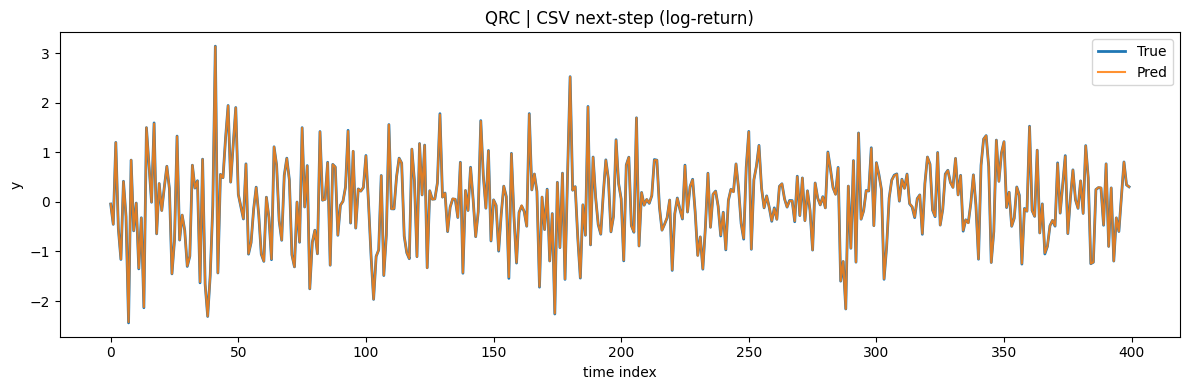

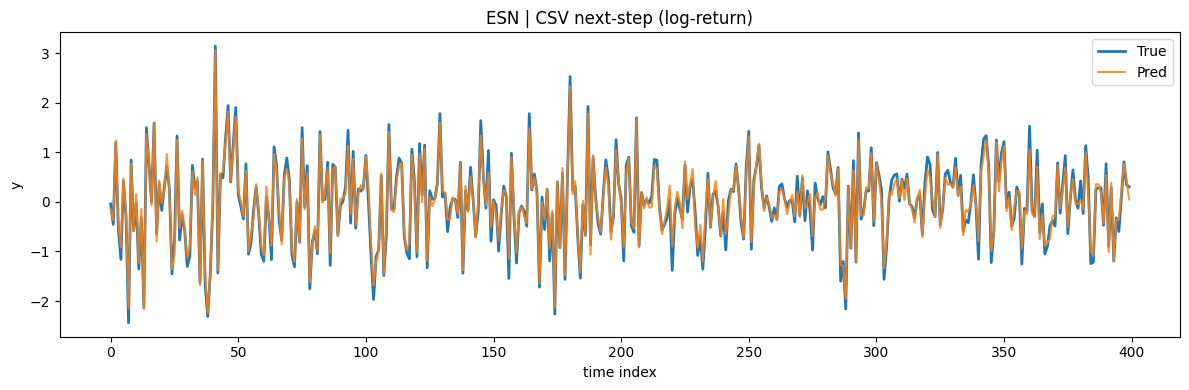

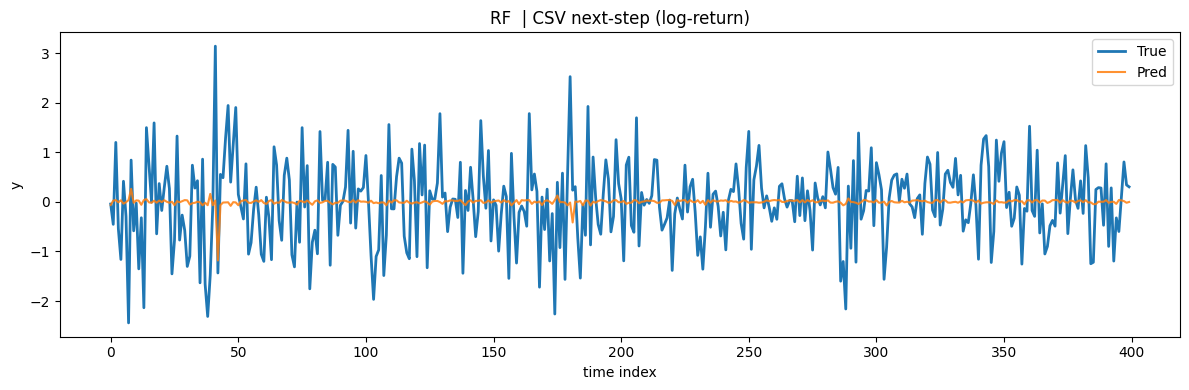

metrics: {'qrc': (3.4662275386198404e-05, 0.9999828002365286), 'esn': (0.023776631413310833, 0.9850734237483266), 'rf': (0.6537930831746486, 0.0815047762326326)}
=== CSV Next-step Prediction | kind=level | M=1200 | T_train=600 ===
[QRC]     MSE=6.85816e-07  Corr=0.999999
[ESN]     MSE=0.00187704  Corr=0.997964
[RF-ESN]  MSE=0.00231091  Corr=0.997493


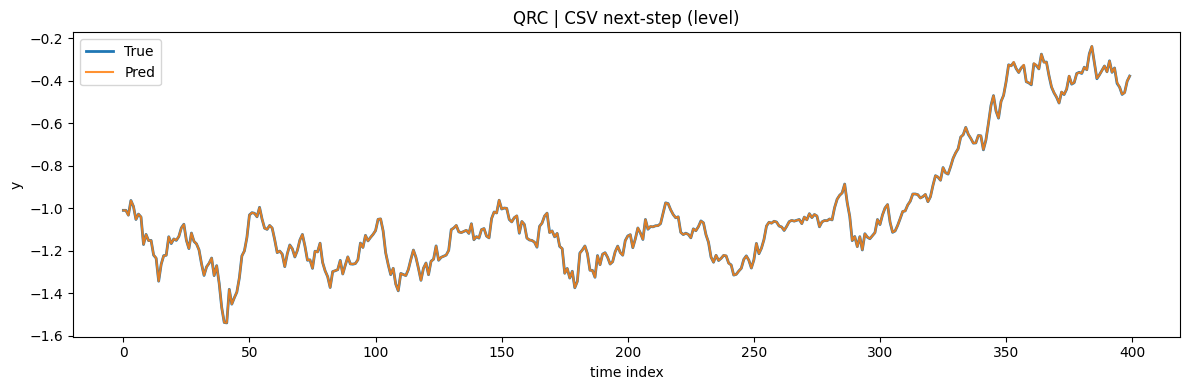

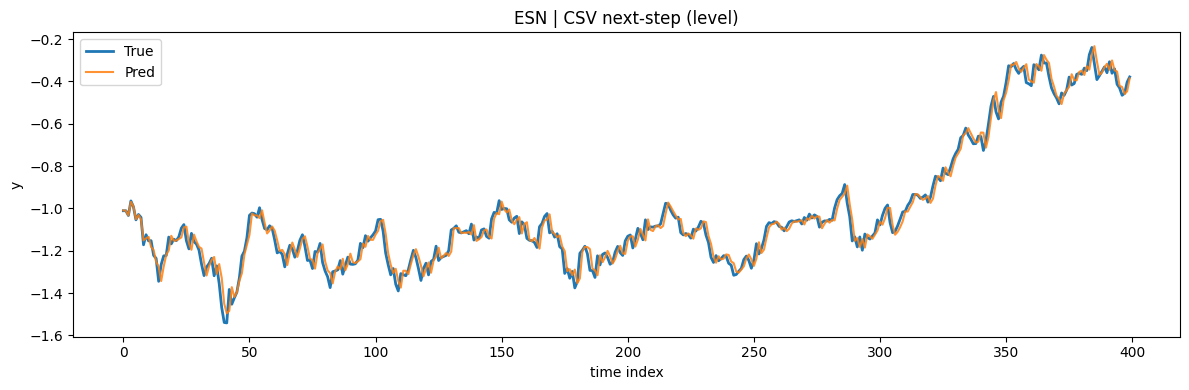

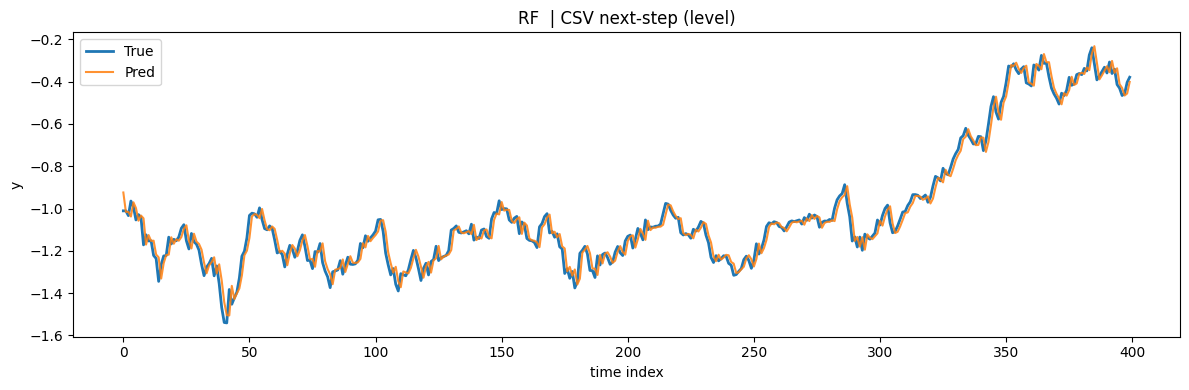

metrics(level): {'qrc': (6.858163260445166e-07, 0.9999992713762873), 'esn': (0.0018770419387595058, 0.9979639006534355), 'rf': (0.0023109075341581713, 0.9974926598698183)}


In [ ]:
# (A) 推奨：log-return で（統計圧縮が効きやすい / 非定常トレンドを除去）
res_csv = compare_three_models_on_csv_nextpred(
    csv_path="nikkei_stock_index_300_daily_jp.csv",
    start_t=0,
    T_train=600,
    use_log_return=True,
    ridge=1e-2,
    N=100,
)

print("metrics:", res_csv["metrics"])

# (B) B列を“そのまま”入力したい場合（ユーザー指定通りの水準系列）
res_csv_level = compare_three_models_on_csv_nextpred(
     csv_path="nikkei_stock_index_300_daily_jp.csv",
     start_t=0,
     T_train=600,
     use_log_return=False,
     ridge=1e-2,
     N=100,
 )

print("metrics(level):", res_csv_level["metrics"])

=== CSV Next-step Prediction | kind=log-return | M=120 | T_train=600 ===
[QRC]     MSE=0.519198  Corr=0.459464
[ESN]     MSE=0.50696  Corr=0.48155
[RF-ESN]  MSE=0.654883  Corr=0.0719886


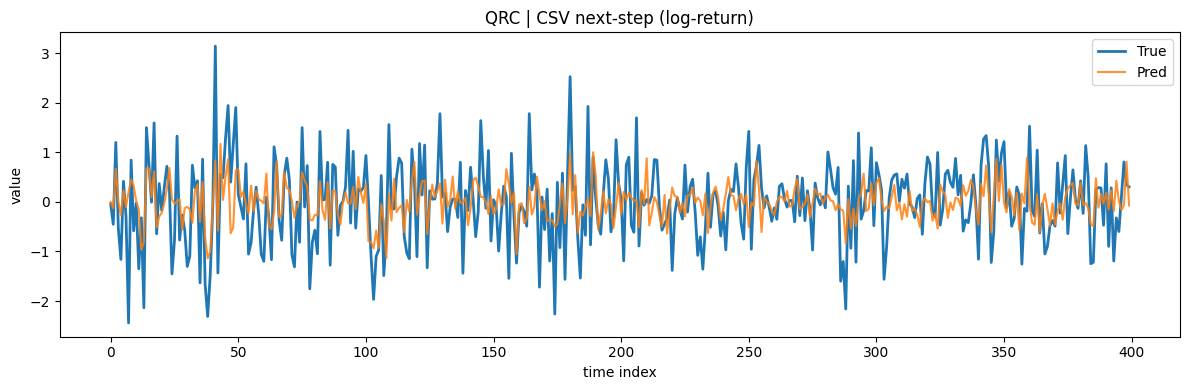

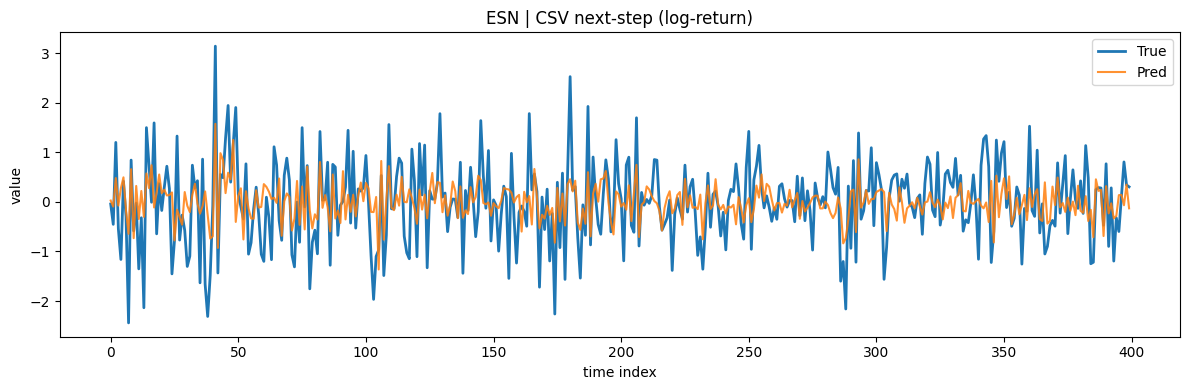

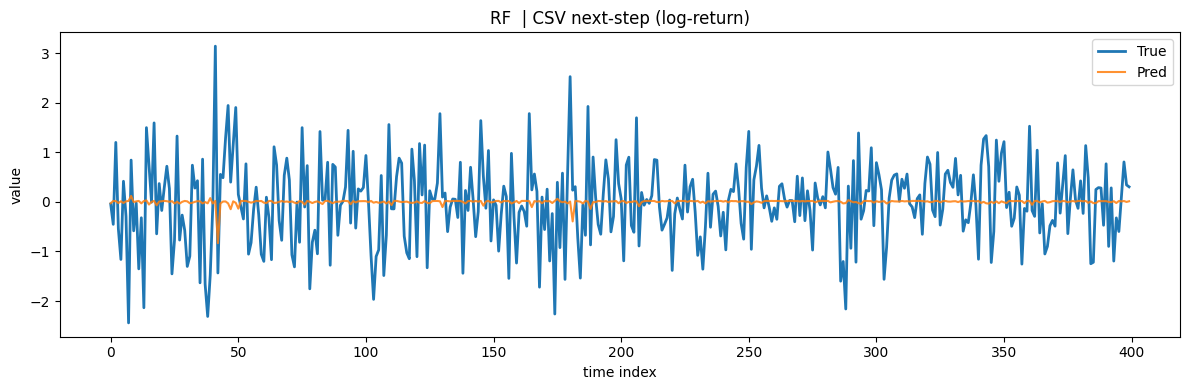

metrics: {'qrc': (0.5191981240242953, 0.45946421570874485), 'esn': (0.5069602865766061, 0.48154960655779755), 'rf': (0.654883329062751, 0.07198860081908617)}
=== CSV Next-step Prediction | kind=level | M=120 | T_train=600 ===
[QRC]     MSE=0.0463471  Corr=0.948448
[ESN]     MSE=0.00221561  Corr=0.997596
[RF-ESN]  MSE=0.00231156  Corr=0.997492


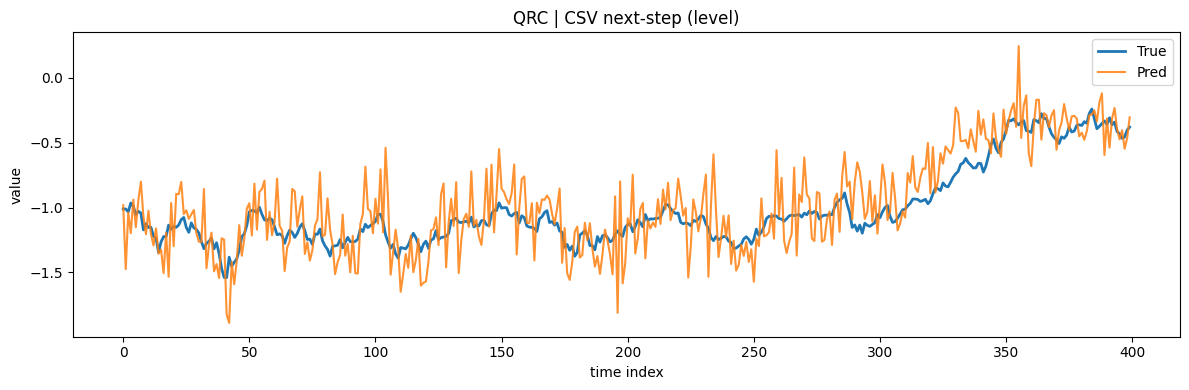

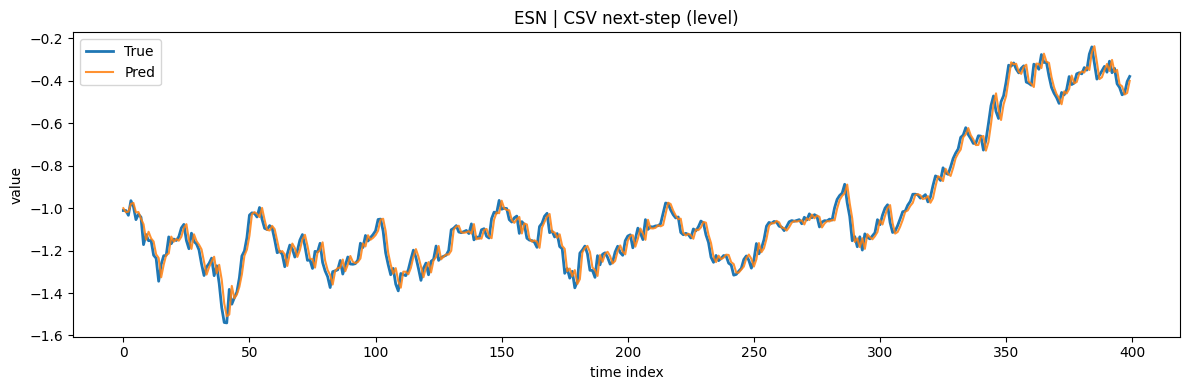

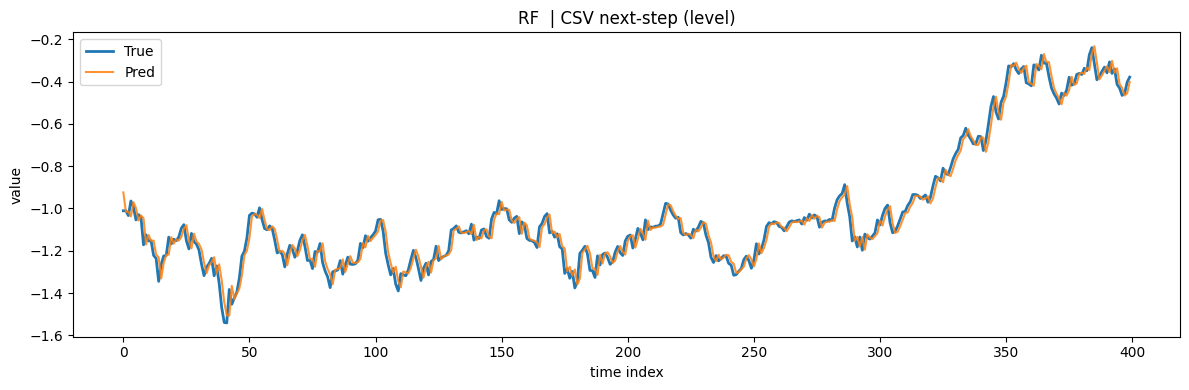

metrics(level): {'qrc': (0.04634711534178102, 0.9484476763208032), 'esn': (0.00221561103278994, 0.9975961839187543), 'rf': (0.002311561379697471, 0.9974919496773725)}


In [ ]:
# (A) 推奨：log-return で（統計圧縮が効きやすい / 非定常トレンドを除去）
res_csv = compare_three_models_on_csv_nextpred(
    csv_path="nikkei_stock_index_300_daily_jp.csv",
    start_t=0,
    T_train=600,
    use_log_return=True,
    ridge=1e-2,
    N=10,
)

print("metrics:", res_csv["metrics"])

# (B) B列を“そのまま”入力したい場合（ユーザー指定通りの水準系列）
res_csv_level = compare_three_models_on_csv_nextpred(
     csv_path="nikkei_stock_index_300_daily_jp.csv",
     start_t=0,
     T_train=600,
     use_log_return=False,
     ridge=1e-2,
     N=10,
 )

print("metrics(level):", res_csv_level["metrics"])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional, Dict

# =========================================================
# 0) Ridge readout（bias付き、biasは正則化しない）
# =========================================================
def fit_readout_ridge(S: np.ndarray, Y: np.ndarray, ridge: float = 1e-2) -> Tuple[np.ndarray, float]:
    S = np.asarray(S, float)
    Y = np.asarray(Y, float).reshape(-1)
    T, M = S.shape
    if Y.size != T:
        raise ValueError("S and Y length mismatch")
    X = np.hstack([S, np.ones((T, 1))])                 # (T, M+1)
    Reg = np.diag(np.append(np.full(M, ridge), 0.0))    # bias not regularized
    theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)
    return theta[:M], float(theta[M])

def predict_readout(S: np.ndarray, w: np.ndarray, b: float) -> np.ndarray:
    return np.asarray(S, float) @ np.asarray(w, float) + float(b)

def mse_corr(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    mse = float(np.mean((y_true - y_pred) ** 2))
    if np.std(y_true) < 1e-12 or np.std(y_pred) < 1e-12:
        corr = np.nan
    else:
        corr = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, corr

def plot_true_vs_pred(y_true, y_pred, *, title="", start=0, length=300):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    end = min(start + length, y_true.size)
    plt.figure(figsize=(12, 4))
    plt.plot(np.arange(start, end), y_true[start:end], label="True", lw=2)
    plt.plot(np.arange(start, end), y_pred[start:end], label="Pred", lw=1.5, alpha=0.85)
    plt.title(title)
    plt.xlabel("time index (test region)")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 1) CSV読み込み（なるべく頑丈）
# =========================================================
def load_csv_time_value(
    csv_path: str,
    *,
    delimiter: str = ",",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    できるだけ頑丈に「時間列」「値列」を読みます。
    - ヘッダあり/なし どちらも許容
    - 2列以上あれば「最初の数値列」を値とみなす（時間は最初の列）
    """
    # まずはnumpyで読み（失敗したらpandasにフォールバック）
    try:
        data = np.genfromtxt(csv_path, delimiter=delimiter, dtype=str)
        if data.ndim == 1:
            # 1行しかない等
            raise ValueError("CSV seems too small or not parsed properly")

        # 先頭行がヘッダっぽい場合を除外するため、数値変換できる行だけ採用
        rows = []
        for r in data:
            if r.size < 2:
                continue
            rows.append(r)
        data = np.array(rows, dtype=str)

        # 値列候補：2列目以降で「floatに変換できる列」を探す
        # 時間列は 0列目（文字列のまま保持してもOK）
        time_raw = data[:, 0]

        val_col = None
        for j in range(1, data.shape[1]):
            try:
                _ = data[:, j].astype(float)
                val_col = j
                break
            except Exception:
                pass
        if val_col is None:
            raise ValueError("No numeric value column found in CSV.")

        value = data[:, val_col].astype(float)

        # timeも「数値なら数値」にしておく（必須ではない）
        try:
            time = time_raw.astype(float)
        except Exception:
            time = np.arange(len(value), dtype=float)

        # NaN除去
        mask = np.isfinite(value)
        time = time[mask]
        value = value[mask]
        return time, value

    except Exception:
        # pandas fallback
        try:
            import pandas as pd
            df = pd.read_csv(csv_path)
            # 時間列：最初の列
            tcol = df.columns[0]
            # 値列：数値列のうち最初（時間列以外）
            num_cols = [c for c in df.columns[1:] if np.issubdtype(df[c].dtype, np.number)]
            if not num_cols:
                # 全部objectでもto_numericで救う
                for c in df.columns[1:]:
                    x = pd.to_numeric(df[c], errors="coerce")
                    if x.notna().sum() > 0:
                        num_cols = [c]
                        df[c] = x
                        break
            if not num_cols:
                raise ValueError("No numeric value column found by pandas fallback.")
            vcol = num_cols[0]
            value = df[vcol].to_numpy(dtype=float)
            # timeは数値化できなければ連番
            try:
                time = pd.to_numeric(df[tcol], errors="coerce").to_numpy(dtype=float)
                if np.all(~np.isfinite(time)):
                    time = np.arange(len(value), dtype=float)
            except Exception:
                time = np.arange(len(value), dtype=float)

            mask = np.isfinite(value)
            return time[mask], value[mask]
        except Exception as e:
            raise RuntimeError(f"Failed to read CSV: {e}")


# =========================================================
# 2) シリーズ変換：level / log-return
# =========================================================
def make_series_from_level(level: np.ndarray, kind: str) -> np.ndarray:
    level = np.asarray(level, float).reshape(-1)
    if kind == "level":
        return level.copy()
    elif kind == "log-return":
        # log-return: r(t) = log(x(t+1)) - log(x(t))
        # xが正でない箇所があると壊れるのでガード
        x = np.clip(level, 1e-12, np.inf)
        r = np.diff(np.log(x))
        return r
    else:
        raise ValueError('kind must be "level" or "log-return".')


# =========================================================
# 3) データセット（1-step予測）
#    入力U[t]=x[t], 教師Y[t]=x[t+1]
# =========================================================
def make_next_step_dataset(x: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, float).reshape(-1)
    if x.size < 3:
        raise ValueError("series too short")
    U = x[:-1]
    Y = x[1:]
    return U, Y


# =========================================================
# 4) あなたのQRC（inject_mask版 out_prob）
# =========================================================
def simulate_qrc_states_outprob_scalar(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U: np.ndarray,
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",       # "pm" or "plus"
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None,  # (M,)
    Win_scale: float = 1.0,
    carry_state: bool = True,
    x0: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    U = np.asarray(U, float).reshape(-1)
    T = U.size
    M = 12 * N
    rng = np.random.default_rng(seed)

    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(M,)) * float(Win_scale)
    else:
        Win = np.asarray(Win, float).reshape(-1)
        if Win.size != M:
            raise ValueError(f"Win must be length {M}")

    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}")
        x_state = np.clip(x_state, 0.0, 1.0)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        u_vec = U[t] * Win
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode != "replace":
            raise ValueError('input_mode must be "scale" or "replace".')

        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / sqrt2

        # safe nonlinearity
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)
        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)

        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    return S, x_state


# =========================================================
# 5) ESN（再帰あり）
# =========================================================
def simulate_esn_states_tanh_scalar(
    M: int,
    U: np.ndarray,
    *,
    seed: int = 43,
    spectral_radius: float = 0.9,
    input_scale: float = 0.5,
    leak_rate: float = 1.0,
    bias_scale: float = 0.1,
) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    U = np.asarray(U, float).reshape(-1)
    T = U.size
    rng = np.random.default_rng(seed)

    Win = rng.uniform(-1.0, 1.0, size=(M,)) * float(input_scale)
    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)
    eigvals = np.linalg.eigvals(Wres)
    sr = np.max(np.abs(eigvals)) + 1e-12
    Wres = Wres * (float(spectral_radius) / sr)
    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    x = np.zeros(M, dtype=float)
    S = np.empty((T, M), dtype=float)
    for t in range(T):
        pre = x @ Wres + (Win * U[t]) + b
        x_new = np.tanh(pre)
        x = (1.0 - leak_rate) * x + leak_rate * x_new
        S[t] = x

    return S, {"Wres": Wres, "Win": Win, "b": b}


# =========================================================
# 6) RF-ESN（再帰なし）= Random Features / ELM
# =========================================================
def simulate_random_features_scalar(
    M: int,
    U: np.ndarray,
    *,
    seed: int = 43,
    input_scale: float = 0.5,
    bias_scale: float = 0.1,
    nonlinearity: str = "tanh",   # "tanh" or "relu"
) -> Dict[str, np.ndarray]:
    U = np.asarray(U, float).reshape(-1)
    T = U.size
    rng = np.random.default_rng(seed)

    Win = rng.uniform(-1.0, 1.0, size=(M,)) * float(input_scale)
    b = rng.uniform(-1.0, 1.0, size=M) * float(bias_scale)

    pre = U[:, None] * Win[None, :] + b[None, :]
    if nonlinearity == "tanh":
        S = np.tanh(pre)
    elif nonlinearity == "relu":
        S = np.maximum(pre, 0.0)
    else:
        raise ValueError('nonlinearity must be "tanh" or "relu".')

    return {"S": S, "Win": Win, "b": b}


# =========================================================
# 7) 正しい評価：trainで学習→testで評価（時系列順）
# =========================================================
def compare_three_models_on_csv_nextpred(
    csv_path: str,
    *,
    kind: str = "log-return",     # "level" or "log-return"
    N: int = 100,                 # QRC: M=12N
    train_len: int = 600,         # 学習に使う点数（Yの点数）
    test_len: int = 600,          # 評価に使う点数（Yの点数）
    washout: int = 200,           # 状態を安定させるために捨てる点数（train先頭から）
    ridge: float = 1e-2,
    # QRC
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    carry_state: bool = True,
    qrc_seed: int = 43,
    qrc_win_scale: float = 1.0,
    # ESN
    esn_seed: int = 43,
    spectral_radius: float = 0.9,
    leak_rate: float = 1.0,
    input_scale_esn: float = 0.5,
    bias_scale_esn: float = 0.1,
    # RF
    rf_seed: int = 43,
    input_scale_rf: float = 0.5,
    bias_scale_rf: float = 0.1,
    rf_nonlinearity: str = "tanh",
    # plot
    plot_len: int = 300,
):
    # ---- load
    t, level = load_csv_time_value(csv_path)
    x = make_series_from_level(level, kind=kind)

    # ---- build next-step dataset
    U_all, Y_all = make_next_step_dataset(x)

    # 使う範囲：train+test+washout分は必要（washoutはtrain内部で捨てる）
    need = washout + train_len + test_len
    if Y_all.size < need:
        raise ValueError(f"Series too short. Need at least {need+1} raw points, got {Y_all.size+1}.")

    # 時系列なので、先頭から連続区間を切り出す
    U = U_all[:need]
    Y = Y_all[:need]

    # split index
    # 学習は [0 : washout+train_len)
    # 評価は [washout+train_len : washout+train_len+test_len)
    idx_train0 = washout
    idx_train1 = washout + train_len
    idx_test0  = idx_train1
    idx_test1  = idx_train1 + test_len

    M = 12 * N

    # ---- QRC states (全区間流すが、readout学習はtrain、評価はtest)
    S_qrc, _ = simulate_qrc_states_outprob_scalar(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U=U,
        seed=qrc_seed,
        norm_const=norm_const,
        sign_mode=sign_mode,
        input_mode=input_mode,
        Win=None,
        Win_scale=qrc_win_scale,
        carry_state=carry_state,
    )

    # ---- ESN states
    S_esn, _ = simulate_esn_states_tanh_scalar(
        M=M, U=U,
        seed=esn_seed,
        spectral_radius=spectral_radius,
        input_scale=input_scale_esn,
        leak_rate=leak_rate,
        bias_scale=bias_scale_esn,
    )

    # ---- RF states
    rf = simulate_random_features_scalar(
        M=M, U=U,
        seed=rf_seed,
        input_scale=input_scale_rf,
        bias_scale=bias_scale_rf,
        nonlinearity=rf_nonlinearity,
    )
    S_rf = rf["S"]

    # ---- train/test slices
    S_q_tr, Y_tr = S_qrc[idx_train0:idx_train1], Y[idx_train0:idx_train1]
    S_q_te, Y_te = S_qrc[idx_test0:idx_test1],  Y[idx_test0:idx_test1]

    S_e_tr, _Ytr = S_esn[idx_train0:idx_train1], Y_tr
    S_e_te, _Yte = S_esn[idx_test0:idx_test1],  Y_te

    S_r_tr = S_rf[idx_train0:idx_train1]
    S_r_te = S_rf[idx_test0:idx_test1]

    # ---- fit on train, eval on test
    wq, bq = fit_readout_ridge(S_q_tr, Y_tr, ridge=ridge)
    Yhat_q = predict_readout(S_q_te, wq, bq)
    mse_q, corr_q = mse_corr(Y_te, Yhat_q)

    we, be = fit_readout_ridge(S_e_tr, Y_tr, ridge=ridge)
    Yhat_e = predict_readout(S_e_te, we, be)
    mse_e, corr_e = mse_corr(Y_te, Yhat_e)

    wr, br = fit_readout_ridge(S_r_tr, Y_tr, ridge=ridge)
    Yhat_r = predict_readout(S_r_te, wr, br)
    mse_r, corr_r = mse_corr(Y_te, Yhat_r)

    # ---- baselines (test only)
    # level: yhat = u(t)  / log-return: yhat = 0 が定番
    U_te = U[idx_test0:idx_test1]
    if kind == "level":
        Yhat_naive = U_te
    else:
        Yhat_naive = np.zeros_like(Y_te)
    mse_n, corr_n = mse_corr(Y_te, Yhat_naive)

    print(f"=== CSV Next-step Prediction (TEST) | kind={kind} | M={M} | train={train_len} test={test_len} washout={washout} ===")
    print(f"[Naive]   MSE={mse_n:.6g}  Corr={corr_n:.6g}")
    print(f"[QRC]     MSE={mse_q:.6g}  Corr={corr_q:.6g}")
    print(f"[ESN]     MSE={mse_e:.6g}  Corr={corr_e:.6g}")
    print(f"[RF-ESN]  MSE={mse_r:.6g}  Corr={corr_r:.6g}")

    # ---- plot (test region)
    plot_true_vs_pred(Y_te, Yhat_naive, title=f"Naive | kind={kind}", start=0, length=plot_len)
    plot_true_vs_pred(Y_te, Yhat_q,     title=f"QRC (TEST) | kind={kind}", start=0, length=plot_len)
    plot_true_vs_pred(Y_te, Yhat_e,     title=f"ESN (TEST) | kind={kind}", start=0, length=plot_len)
    plot_true_vs_pred(Y_te, Yhat_r,     title=f"RF (TEST) | kind={kind}", start=0, length=plot_len)

    return {
        "Y_test": Y_te,
        "pred_naive": Yhat_naive,
        "pred_qrc": Yhat_q,
        "pred_esn": Yhat_e,
        "pred_rf": Yhat_r,
        "metrics": {
            "naive": (mse_n, corr_n),
            "qrc":   (mse_q, corr_q),
            "esn":   (mse_e, corr_e),
            "rf":    (mse_r, corr_r),
        }
    }

=== CSV Next-step Prediction (TEST) | kind=log-return | M=1200 | train=550 test=300 washout=100 ===
[Naive]   MSE=0.00016616  Corr=nan
[QRC]     MSE=0.000347847  Corr=-0.0438698
[ESN]     MSE=0.000166974  Corr=0.0901092
[RF-ESN]  MSE=0.000165384  Corr=0.179928


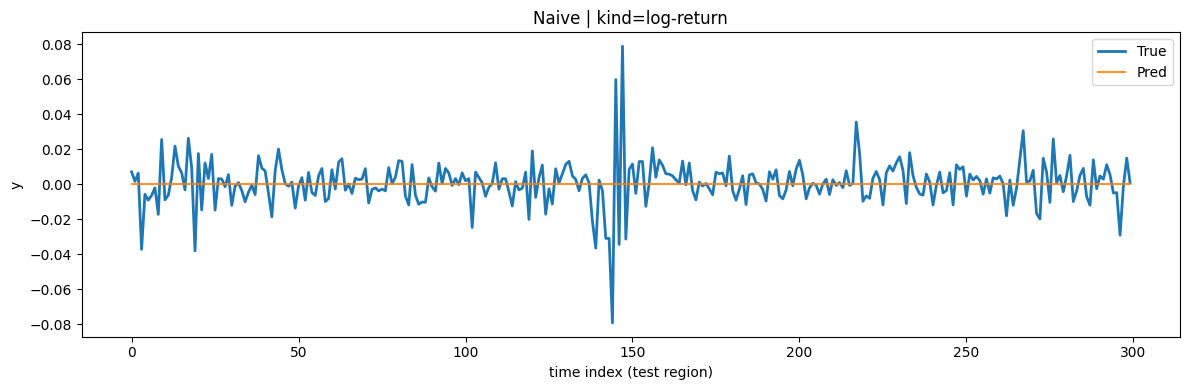

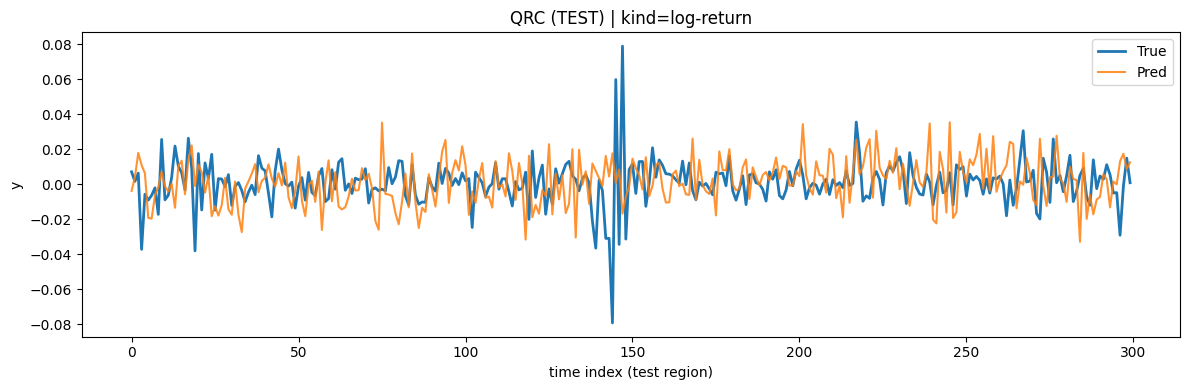

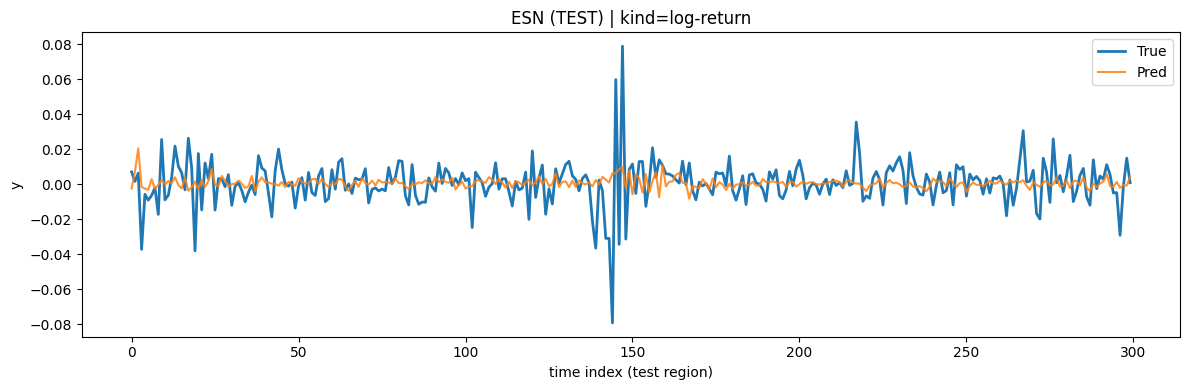

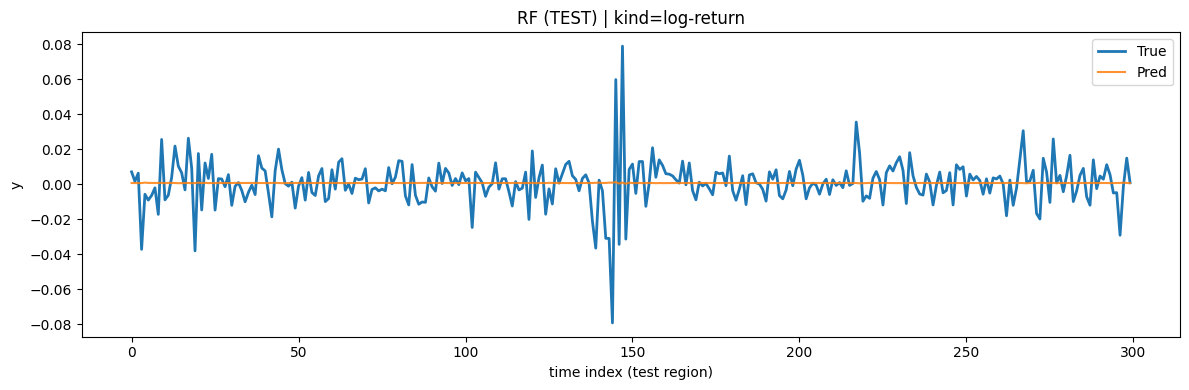

=== CSV Next-step Prediction (TEST) | kind=level | M=1200 | train=550 test=300 washout=100 ===
[Naive]   MSE=55.1377  Corr=0.986622
[QRC]     MSE=1006.31  Corr=0.853405
[ESN]     MSE=102.168  Corr=0.98512
[RF-ESN]  MSE=121.211  Corr=0.985307


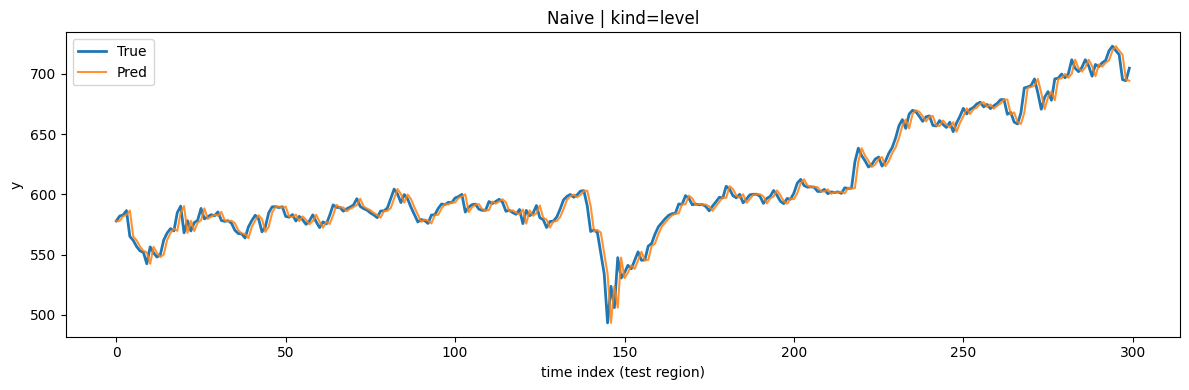

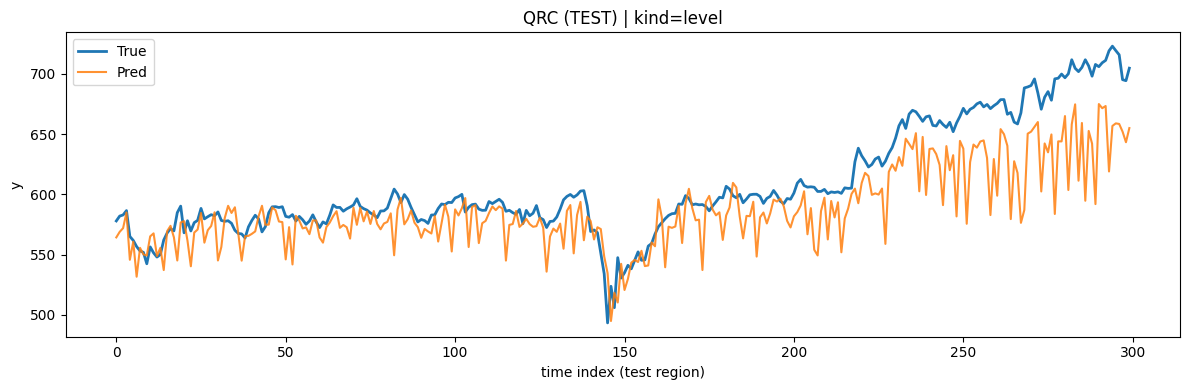

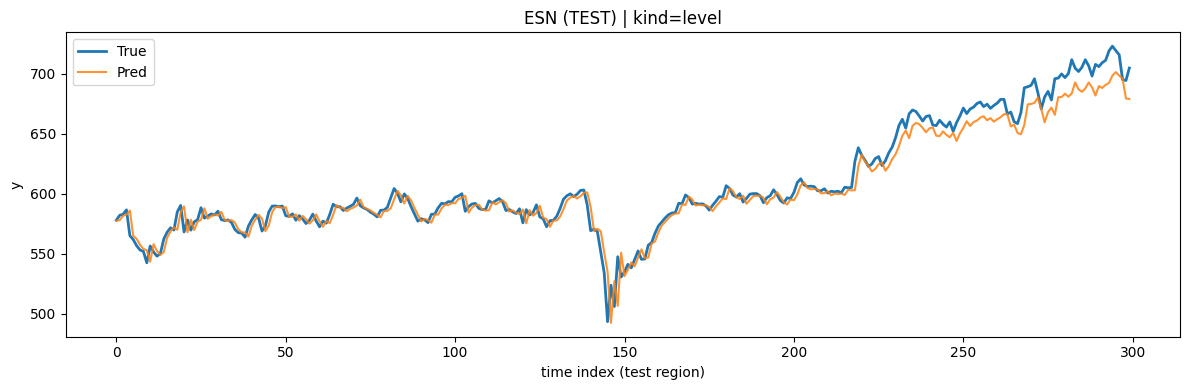

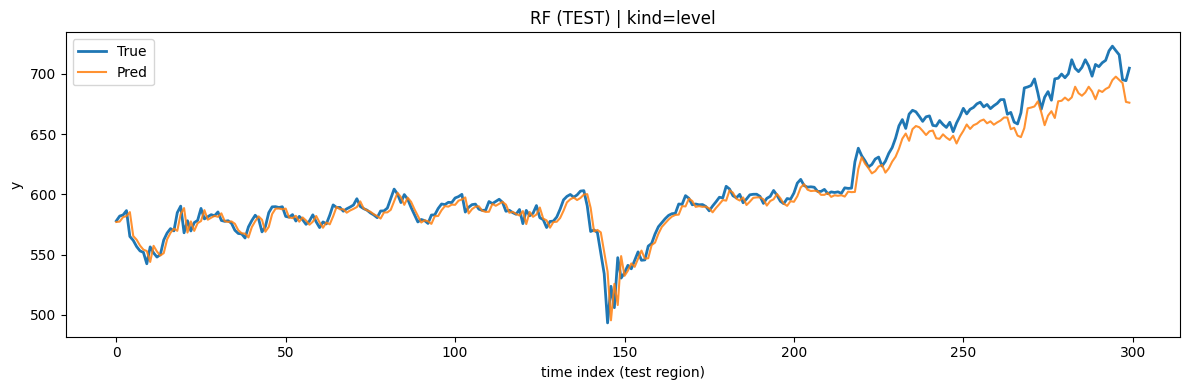

In [ ]:
if __name__ == "__main__":
    # ★あなたのCSVに合わせてパスを変更してください
    csv_path = "nikkei_stock_index_300_daily_jp.csv"

    # log-return で評価
    res_ret = compare_three_models_on_csv_nextpred(
        csv_path,
        kind="log-return",
        N=100,
        train_len=550,
        test_len=300,
        washout=100,
        ridge=1e-2,
        alpha=1.0, beta=0.7, squeeze_r=0.3,
        carry_state=True,
    )

    # level で評価（ナイーブが強いので注意）
    res_lvl = compare_three_models_on_csv_nextpred(
        csv_path,
        kind="level",
        N=100,
        train_len=550,
        test_len=300,
        washout=100,
        ridge=1e-2,
        alpha=1.0, beta=0.7, squeeze_r=0.3,
        carry_state=True,
    )

# **MNIST分類タスク**

In [ ]:
import numpy as np
from typing import Tuple, Optional

def simulate_and_fit_one_pass_window10_multiclass(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,                  # (T,10)
    y_label: np.ndarray,              # (T,) 0..9
    *,
    ridge: float = 1e-2,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",          # "pm" or "plus"
    input_mode: str = "scale",        # "scale" or "replace"
    Win: Optional[np.ndarray] = None, # (10,M)
    Win_scale: float = 1.0,
    x0: Optional[np.ndarray] = None,  # (M,)
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    出力:
      Wout: (M,10)
      b:    (10,)
      y_hat_label: (T,) 予測ラベル
      S:    (T,M) 状態列（out_prob）
      xT:   (M,)  最終状態（無励起確率）
    """
    U10 = np.asarray(U10, dtype=float)
    y_label = np.asarray(y_label, dtype=int).reshape(-1)

    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError(f"U10 must be (T,10). got {U10.shape}")
    T = U10.shape[0]
    if y_label.size != T:
        raise ValueError(f"y_label must be length T={T}. got {y_label.size}")

    M = 12 * N
    rng = np.random.default_rng(seed)

    # Win: (10,M)
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, dtype=float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be shape (10,{M}). got {Win.shape}")

    # x_state: (M,) (no-excitation prob)
    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, dtype=float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}. got {x_state.size}")
        x_state = np.clip(x_state, 0.0, 1.0)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    # 状態列
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # (A) 10 -> M 入力
        u_vec = U10[t] @ Win  # (M,)

        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # (B) 注入
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # (C) 干渉ネットワーク
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        # (D) 合成
        fin = (wnet + u_vec) / sqrt2

        # (E) 非線形：out_prob
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)

        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)
        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        # ---- ここから置換：shots回サンプリング平均を状態にする ----
        shots_i = int(max(1, shots))
        flip_p_f = float(np.clip(flip_p, 0.0, 1.0))

        samples_sum = np.zeros(M, dtype=float)
        for _ in range(shots_i):
            sample = (rng.random(M) < out_prob).astype(np.int8)  # 0/1
            if flip_p_f > 0.0:
                flip = (rng.random(M) < flip_p_f).astype(np.int8)
                sample = sample ^ flip
            samples_sum += sample.astype(float)

        out_mean01 = samples_sum / shots_i

        S[t] = out_mean01

        # 状態更新（無励起確率として）
        if carry_state:
            x_state = np.clip(1.0 - out_mean01, 0.0, 1.0)

    xT = x_state.copy()

    # =========================
    # multi-class ridge:  Y = X @ Theta
    # X: (T, M+1), Y: (T,10)
    # =========================
    X = np.hstack([S, np.ones((T, 1))])  # (T, M+1)

    Y = np.zeros((T, 10), dtype=float)
    Y[np.arange(T), y_label] = 1.0

    Reg = np.diag(np.append(np.full(M, ridge), 0.0))   # biasは正則化しない
    Theta = np.linalg.solve(X.T @ X + Reg, X.T @ Y)    # (M+1, 10)

    Wout = Theta[:M, :]               # (M,10)
    b = Theta[M, :]                   # (10,)
    scores = S @ Wout + b[None, :]    # (T,10)
    y_hat_label = scores.argmax(axis=1)

    return Wout, b, y_hat_label, S, xT

In [ ]:
import numpy as np
from typing import Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================================================
# 1) MNIST loader
# ============================================================
def load_mnist() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    returns:
      x_train: uint8 (N,28,28)
      y_train: int  (N,)
      x_test : uint8 (N,28,28)
      y_test : int  (N,)
    """
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        return x_train, y_train.astype(int), x_test, y_test.astype(int)
    except Exception as e:
        raise RuntimeError("MNISTを読み込めませんでした。tensorflow.keras を用意してください。") from e


# ============================================================
# 2) 10x10 sliding patches stride=2 -> T=100, patch dim=100
# ============================================================
def patches_10x10_stride2(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: patches (T=100, 100) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0

    H, W = img.shape
    stride = 2
    ys = range(0, H - 10 + 1, stride)  # 0..18 step2 => 10 positions
    xs = range(0, W - 10 + 1, stride)  # 10 positions
    patches = []
    for y in ys:
        for x in xs:
            p = img[y:y+10, x:x+10].reshape(-1)  # 100
            patches.append(p)
    return np.stack(patches, axis=0)  # (100,100)


def build_projection_A10x100(seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    # 10x100, scale ~ 1/sqrt(100) で安定化
    A = rng.normal(0.0, 1.0/np.sqrt(100.0), size=(10, 100))
    return A


def patches_to_U10(patches: np.ndarray, A10x100: np.ndarray) -> np.ndarray:
    """
    patches: (T,100)
    A10x100: (10,100)
    return: U10 (T,10)
    """
    # (T,10) = (T,100) @ (100,10)
    U10 = patches @ A10x100.T
    return U10.astype(np.float64)


# ============================================================
# 3) QRC forward: これは simulate_and_fit_one_pass_window10_multiclass の
#    「状態列 S を作る部分」をそのまま抜き出したものです（同一力学）
# ============================================================
def qrc_forward_states_window10(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,                  # (T,10)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None, # (10,M)
    Win_scale: float = 1.0,
    x0: Optional[np.ndarray] = None,  # (M,)
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    return:
      S : (T,M)  out_prob 状態列
      xT: (M,)   最終状態（無励起確率）
      Win: (10,M) 使用した入力マスク（再利用用）
    """
    U10 = np.asarray(U10, dtype=float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError(f"U10 must be (T,10). got {U10.shape}")
    T = U10.shape[0]

    M = 12 * N
    rng = np.random.default_rng(seed)

    # Win
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, dtype=float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be shape (10,{M}). got {Win.shape}")

    # initial state (no-excitation prob)
    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, dtype=float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}. got {x_state.size}")
        x_state = np.clip(x_state, 0.0, 1.0)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # (A) 10 -> M
        u_vec = U10[t] @ Win  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # (B) injection
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # (C) interferometer
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        # (D) combine
        fin = (wnet + u_vec) / sqrt2

        # (E) nonlinearity -> out_prob (numerically stabilized)
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)

        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)
        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)  # overflow guard
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        # (F) state update
        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    xT = x_state.copy()
    return S, xT, Win


# ============================================================
# 4) 1画像 -> QRC特徴 (M,) を作る（ここでは time-mean pooling）
# ============================================================
def qrc_feature_from_image(
    img28: np.ndarray,
    *,
    A10x100: np.ndarray,
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    seed_qrc: int,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None,
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray]:
    patches = patches_10x10_stride2(img28)       # (100,100)
    U10 = patches_to_U10(patches, A10x100)       # (100,10)

    S, xT, Win_used = qrc_forward_states_window10(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U10=U10,
        seed=seed_qrc, norm_const=norm_const,
        sign_mode=sign_mode, input_mode=input_mode,
        Win=Win, Win_scale=Win_scale,
        x0=None, carry_state=carry_state
    )

    # 代表特徴：時刻平均（他に mean+std などにしてもOK）
    feat = S.mean(axis=0)  # (M,)
    return feat.astype(np.float32), Win_used


# ============================================================
# 5) 全体：MNIST -> QRC特徴 -> ロジ回帰
# ============================================================
def run_mnist_qrc_logreg(
    *,
    n_train: int = 6000,
    n_test: int = 1000,
    # QRC params
    N: int = 100,            # M=12N
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,
    carry_state: bool = True,
    # seeds
    seed_data: int = 123,
    seed_proj: int = 0,
    seed_qrc: int = 43,
):
    x_train, y_train, x_test, y_test = load_mnist()

    rng = np.random.default_rng(seed_data)
    idx_tr = rng.choice(len(x_train), size=n_train, replace=False)
    idx_te = rng.choice(len(x_test),  size=n_test,  replace=False)
    Xtr_img = x_train[idx_tr]
    ytr = y_train[idx_tr]
    Xte_img = x_test[idx_te]
    yte = y_test[idx_te]

    # patch(100) -> 10 の固定射影
    A = build_projection_A10x100(seed=seed_proj)

    # 特徴抽出（Winは全画像で固定にするのが普通なので、最初に生成して以後再利用）
    Win_fixed = None

    Phi_tr = []
    for img in Xtr_img:
        feat, Win_fixed = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state
        )
        Phi_tr.append(feat)
    Phi_tr = np.stack(Phi_tr, axis=0)  # (n_train, M)

    Phi_te = []
    for img in Xte_img:
        feat, _ = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state
        )
        Phi_te.append(feat)
    Phi_te = np.stack(Phi_te, axis=0)  # (n_test, M)

    # 標準化 + ロジ回帰
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Phi_tr)
    Xte = scaler.transform(Phi_te)

    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=400,
        multi_class="multinomial"
    )
    clf.fit(Xtr, ytr)

    pred_tr = clf.predict(Xtr)
    pred_te = clf.predict(Xte)

    acc_tr = accuracy_score(ytr, pred_tr)
    acc_te = accuracy_score(yte, pred_te)

    print(f"[Train] acc={acc_tr:.4f}")
    print(f"[Test ] acc={acc_te:.4f}")
    print("\nConfusion matrix (test):")
    print(confusion_matrix(yte, pred_te))
    print("\nClassification report (test):")
    print(classification_report(yte, pred_te, digits=4))

    return acc_tr, acc_te, clf, scaler, Win_fixed, A

In [ ]:
# 例：実行
if __name__ == "__main__":
    run_mnist_qrc_logreg(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.8200

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  5  1  0  1  1  0  1  0]
 [ 0  0  0  8  0  1  1  0  0  0]
 [ 0  0  0  0  5  0  1  0  0  1]
 [ 0  0  0  1  0 11  1  0  0  0]
 [ 0  1  0  0  0  0  7  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 0  0  0  1  0  0  0  0  7  1]
 [ 0  0  0  1  1  1  0  0  0 13]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     0.9333    1.0000    0.9655        14
           2     0.8333    0.5556    0.6667         9
           3     0.6667    0.8000    0.7273        10
           4     0.8333    0.7143    0.7692         7
           5     0.7857    0.8462    0.8148        13
           6     0.6364    0.8750    0.7368         8
           7     1.0000    0.7500    0.8571         8
           8     0.8750    0.7778    0.8235         9
           9     0.8125    0.8125

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg(
        n_train=6000,
        n_test=1000,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.9420

Confusion matrix (test):
[[ 92   0   0   0   0   0   0   0   0   0]
 [  0 108   1   1   0   0   1   0   0   0]
 [  0   0  89   1   0   3   0   2   3   2]
 [  0   0   2 104   0   0   0   2   1   1]
 [  0   0   0   0  87   0   3   0   0   7]
 [  1   0   0   1   0  90   0   1   0   0]
 [  3   1   2   0   0   0  91   0   0   0]
 [  0   1   1   1   3   0   0  86   1   1]
 [  0   1   1   0   1   1   0   0  97   1]
 [  1   0   0   2   0   0   0   2   1  98]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.9485    1.0000    0.9735        92
           1     0.9730    0.9730    0.9730       111
           2     0.9271    0.8900    0.9082       100
           3     0.9455    0.9455    0.9455       110
           4     0.9560    0.8969    0.9255        97
           5     0.9574    0.9677    0.9626        93
           6     0.9579    0.9381    0.9479        97
           7     0.9247    0.9149    0.91

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_logreg(
        n_train=60000,
        n_test=10000,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[Train] acc=0.9995
[Test ] acc=0.9553

Confusion matrix (test):
[[ 956    1    2    0    1    2    8    3    5    2]
 [   0 1127    4    0    1    0    0    1    2    0]
 [   3    4  980   13    5    8    3    5    9    2]
 [   3    0    8  968    0   14    0    4    6    7]
 [   3    0    2    1  938    0    9    5    3   21]
 [   3    1    2   17    1  852    4    2    7    3]
 [  10    2    5    0   10    6  917    1    7    0]
 [   1    7   11   10    8    3    0  972    2   14]
 [   7    3    7    9    5    7    8    3  908   17]
 [   5    2    2    8   23   12    0    9   13  935]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.9647    0.9755    0.9701       980
           1     0.9826    0.9930    0.9877      1135
           2     0.9580    0.9496    0.9538      1032
           3     0.9435    0.9584    0.9509      1010
           4     0.9456    0.9552    0.9504       982
           5     0.9425    0.9552    0.9488      

**学習においてもノイズを入れてみる**

In [ ]:
import numpy as np
from typing import Tuple, Optional

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# ============================================================
# 0) Noisy teacher utilities (NEW)
# ============================================================
def make_noisy_targets(
    y: np.ndarray,
    num_classes: int = 10,
    noise_scale: float = 0.05,
    *,
    rng: np.random.Generator,
    noise_dist: str = "uniform",   # "uniform" or "normal"
    clip_nonneg: bool = True,
    renorm: str = "sum",           # "sum" -> row sum = 1
) -> np.ndarray:
    """
    y: (N,) labels 0..9
    return: Y_soft (N,10)
      one-hot に各要素独立ノイズVを足して正規化した確率ベクトル
    """
    y = np.asarray(y, dtype=int).ravel()
    N = y.size

    Y = np.zeros((N, num_classes), dtype=np.float64)
    Y[np.arange(N), y] = 1.0

    if noise_dist == "uniform":
        V = rng.uniform(-noise_scale, noise_scale, size=Y.shape)
    elif noise_dist == "normal":
        V = rng.normal(0.0, noise_scale, size=Y.shape)
    else:
        raise ValueError('noise_dist must be "uniform" or "normal".')

    Y = Y + V

    if clip_nonneg:
        Y = np.clip(Y, 0.0, None)

    if renorm == "sum":
        s = Y.sum(axis=1, keepdims=True)
        s = np.where(s <= 1e-12, 1.0, s)  # all-zero safety
        Y = Y / s
    else:
        raise ValueError('renorm must be "sum".')

    return Y


def fit_ridge_multiclass_noisy_teacher(
    Phi_tr: np.ndarray,
    y_tr: np.ndarray,
    ridge: float = 1e-2,
    *,
    noise_scale: float = 0.05,
    seed: int = 0,
    noise_dist: str = "uniform",
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Phi_tr: (N,D)
    y_tr  : (N,)
    return:
      W : (D+1,10)   (last row is bias)
      mu: (D,)
      sd: (D,)
    """
    Phi_tr = np.asarray(Phi_tr, dtype=np.float64)
    y_tr = np.asarray(y_tr, dtype=int).ravel()

    Nn, D = Phi_tr.shape
    C = 10

    mu = Phi_tr.mean(axis=0, keepdims=True)
    sd = Phi_tr.std(axis=0, keepdims=True) + 1e-8
    X = (Phi_tr - mu) / sd
    X = np.hstack([X, np.ones((Nn, 1), dtype=X.dtype)])  # bias

    rng = np.random.default_rng(seed)
    Y_soft = make_noisy_targets(
        y_tr, num_classes=C, noise_scale=noise_scale,
        rng=rng, noise_dist=noise_dist, clip_nonneg=False, renorm="sum"
    )

    Reg = np.diag(np.append(np.full(D, ridge, dtype=X.dtype), 0.0))  # bias no reg
    W = np.linalg.solve(X.T @ X + Reg, X.T @ Y_soft)  # (D+1,10)
    return W, mu.ravel(), sd.ravel()


def predict_multiclass(
    Phi: np.ndarray,
    W: np.ndarray,
    mu: np.ndarray,
    sd: np.ndarray
) -> np.ndarray:
    Phi = np.asarray(Phi, dtype=np.float64)
    X = (Phi - mu) / sd
    X = np.hstack([X, np.ones((X.shape[0], 1), dtype=X.dtype)])
    scores = X @ W  # (N,10)
    return scores.argmax(axis=1)


# ============================================================
# 1) MNIST loader
# ============================================================
def load_mnist() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    returns:
      x_train: uint8 (N,28,28)
      y_train: int  (N,)
      x_test : uint8 (N,28,28)
      y_test : int  (N,)
    """
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        return x_train, y_train.astype(int), x_test, y_test.astype(int)
    except Exception as e:
        raise RuntimeError("MNISTを読み込めませんでした。tensorflow.keras を用意してください。") from e


# ============================================================
# 2) 10x10 sliding patches stride=2 -> T=100, patch dim=100
# ============================================================
def patches_10x10_stride2(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: patches (T=100, 100) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0

    H, W = img.shape
    stride = 2
    ys = range(0, H - 10 + 1, stride)  # 0..18 step2 => 10 positions
    xs = range(0, W - 10 + 1, stride)  # 10 positions
    patches = []
    for y in ys:
        for x in xs:
            p = img[y:y+10, x:x+10].reshape(-1)  # 100
            patches.append(p)
    return np.stack(patches, axis=0)  # (100,100)


def build_projection_A10x100(seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    A = rng.normal(0.0, 1.0/np.sqrt(100.0), size=(10, 100))
    return A


def patches_to_U10(patches: np.ndarray, A10x100: np.ndarray) -> np.ndarray:
    """
    patches: (T,100)
    A10x100: (10,100)
    return: U10 (T,10)
    """
    U10 = patches @ A10x100.T  # (T,10)
    return U10.astype(np.float64)


# ============================================================
# 3) QRC forward -> states S (your code)
# ============================================================
def qrc_forward_states_window10(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,                  # (T,10)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None, # (10,M)
    Win_scale: float = 1.0,
    x0: Optional[np.ndarray] = None,  # (M,)
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    return:
      S : (T,M)  out_prob states
      xT: (M,)   final state (no-excitation prob)
      Win: (10,M)
    """
    U10 = np.asarray(U10, dtype=float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError(f"U10 must be (T,10). got {U10.shape}")
    T = U10.shape[0]

    M = 12 * N
    rng = np.random.default_rng(seed)

    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, dtype=float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be shape (10,{M}). got {Win.shape}")

    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, dtype=float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}. got {x_state.size}")
        x_state = np.clip(x_state, 0.0, 1.0)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    for t in range(T):
        u_vec = U10[t] @ Win  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        fin = (wnet + u_vec) / sqrt2

        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)

        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)
        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        S[t] = out_prob

        if carry_state:
            x_state = np.clip(1.0 - out_prob, 0.0, 1.0)

    xT = x_state.copy()
    return S, xT, Win


# ============================================================
# 4) 1 image -> QRC feature (time-mean pooling)
# ============================================================
def qrc_feature_from_image(
    img28: np.ndarray,
    *,
    A10x100: np.ndarray,
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    seed_qrc: int,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None,
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray]:
    patches = patches_10x10_stride2(img28)       # (100,100)
    U10 = patches_to_U10(patches, A10x100)       # (100,10)

    S, xT, Win_used = qrc_forward_states_window10(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U10=U10,
        seed=seed_qrc, norm_const=norm_const,
        sign_mode=sign_mode, input_mode=input_mode,
        Win=Win, Win_scale=Win_scale,
        x0=None, carry_state=carry_state
    )

    feat = S.mean(axis=0)  # (M,)
    return feat.astype(np.float32), Win_used


# ============================================================
# 5) Main: MNIST -> QRC features -> (Noisy-teacher) Ridge multiclass
# ============================================================
def run_mnist_qrc_noisy_teacher_ridge(
    *,
    n_train: int = 6000,
    n_test: int = 1000,
    # QRC params
    N: int = 100,            # M=12N
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,
    carry_state: bool = True,
    # training params
    ridge: float = 1e-2,
    noise_scale: float = 0.05,
    noise_seed: int = 999,
    noise_dist: str = "uniform",
    # seeds
    seed_data: int = 123,
    seed_proj: int = 0,
    seed_qrc: int = 43,
):
    x_train, y_train, x_test, y_test = load_mnist()

    rng = np.random.default_rng(seed_data)
    idx_tr = rng.choice(len(x_train), size=n_train, replace=False)
    idx_te = rng.choice(len(x_test),  size=n_test,  replace=False)
    Xtr_img = x_train[idx_tr]
    ytr = y_train[idx_tr]
    Xte_img = x_test[idx_te]
    yte = y_test[idx_te]

    A = build_projection_A10x100(seed=seed_proj)

    Win_fixed = None

    Phi_tr = []
    for img in Xtr_img:
        feat, Win_fixed = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state
        )
        Phi_tr.append(feat)
    Phi_tr = np.stack(Phi_tr, axis=0)  # (n_train, M)

    Phi_te = []
    for img in Xte_img:
        feat, _ = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state
        )
        Phi_te.append(feat)
    Phi_te = np.stack(Phi_te, axis=0)  # (n_test, M)

    # ★ Noisy-teacher ridge multiclass
    W, mu, sd = fit_ridge_multiclass_noisy_teacher(
        Phi_tr, ytr, ridge=ridge,
        noise_scale=noise_scale,
        seed=noise_seed,
        noise_dist=noise_dist
    )

    pred_tr = predict_multiclass(Phi_tr, W, mu, sd)
    pred_te = predict_multiclass(Phi_te, W, mu, sd)

    acc_tr = accuracy_score(ytr, pred_tr)
    acc_te = accuracy_score(yte, pred_te)

    print(f"[Train] acc={acc_tr:.4f}")
    print(f"[Test ] acc={acc_te:.4f}")
    print("\nConfusion matrix (test):")
    print(confusion_matrix(yte, pred_te))
    print("\nClassification report (test):")
    print(classification_report(yte, pred_te, digits=4))

    return acc_tr, acc_te, W, mu, sd, Win_fixed, A

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_noisy_teacher_ridge(
        n_train=600,
        n_test=100,
        N=100,
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        ridge=1e-2,
        noise_scale=0.0,
        noise_seed=999,
        noise_dist="uniform",
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True,
    )

[Train] acc=1.0000
[Test ] acc=0.7600

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  4  1  0  0  1  2  1  0]
 [ 0  0  1  7  0  0  0  1  1  0]
 [ 0  0  0  0  4  0  1  1  0  1]
 [ 0  0  0  0  0 11  1  0  0  1]
 [ 0  0  0  0  1  0  7  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 0  1  0  2  0  0  0  0  4  2]
 [ 0  0  0  0  1  0  0  1  1 13]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     0.9333    1.0000    0.9655        14
           2     0.6667    0.4444    0.5333         9
           3     0.7000    0.7000    0.7000        10
           4     0.6667    0.5714    0.6154         7
           5     1.0000    0.8462    0.9167        13
           6     0.7000    0.8750    0.7778         8
           7     0.5455    0.7500    0.6316         8
           8     0.5714    0.4444    0.5000         9
           9     0.7222    0.8125

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_noisy_teacher_ridge(
        n_train=600,
        n_test=100,
        N=100,
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        ridge=1e-2,
        noise_scale=0.001,
        noise_seed=999,
        noise_dist="uniform",
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True,
    )

[Train] acc=1.0000
[Test ] acc=0.7600

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  4  1  0  0  1  2  1  0]
 [ 0  0  1  7  0  0  0  1  1  0]
 [ 0  0  0  0  4  0  1  1  0  1]
 [ 0  0  0  0  0 11  1  0  0  1]
 [ 0  0  0  0  1  0  7  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 0  1  0  2  0  0  0  0  4  2]
 [ 0  0  0  0  1  0  0  1  1 13]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     0.9333    1.0000    0.9655        14
           2     0.6667    0.4444    0.5333         9
           3     0.7000    0.7000    0.7000        10
           4     0.6667    0.5714    0.6154         7
           5     1.0000    0.8462    0.9167        13
           6     0.7000    0.8750    0.7778         8
           7     0.5455    0.7500    0.6316         8
           8     0.5714    0.4444    0.5000         9
           9     0.7222    0.8125

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_noisy_teacher_ridge(
        n_train=600,
        n_test=100,
        N=100,
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        ridge=1e-2,
        noise_scale=0.05,
        noise_seed=999,
        noise_dist="uniform",
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True,
    )

[Train] acc=1.0000
[Test ] acc=0.7800

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  4  1  0  1  1  1  1  0]
 [ 0  0  1  7  0  0  0  1  1  0]
 [ 0  0  0  0  4  0  1  1  0  1]
 [ 0  0  0  0  0 11  1  0  0  1]
 [ 0  0  0  0  1  0  7  0  0  0]
 [ 0  0  1  0  0  0  0  7  0  0]
 [ 0  1  0  2  0  0  0  0  5  1]
 [ 0  0  0  0  1  0  0  1  1 13]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     0.9333    1.0000    0.9655        14
           2     0.6667    0.4444    0.5333         9
           3     0.7000    0.7000    0.7000        10
           4     0.6667    0.5714    0.6154         7
           5     0.9167    0.8462    0.8800        13
           6     0.7000    0.8750    0.7778         8
           7     0.6364    0.8750    0.7368         8
           8     0.6250    0.5556    0.5882         9
           9     0.8125    0.8125

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_noisy_teacher_ridge(
        n_train=600,
        n_test=100,
        N=100,
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        ridge=1e-2,
        noise_scale=0.05,
        noise_seed=999,
        noise_dist="uniform",
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True,
    )

[Train] acc=1.0000
[Test ] acc=0.7800

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  4  1  0  1  1  1  1  0]
 [ 0  0  1  7  0  0  1  0  1  0]
 [ 0  0  0  0  4  0  1  1  0  1]
 [ 0  0  0  0  0 11  1  0  0  1]
 [ 0  0  0  0  0  0  7  1  0  0]
 [ 0  0  1  0  0  0  0  7  0  0]
 [ 0  0  0  2  0  0  0  0  6  1]
 [ 0  0  1  0  1  0  0  1  1 12]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     1.0000    1.0000    1.0000        14
           2     0.5714    0.4444    0.5000         9
           3     0.7000    0.7000    0.7000        10
           4     0.8000    0.5714    0.6667         7
           5     0.9167    0.8462    0.8800        13
           6     0.6364    0.8750    0.7368         8
           7     0.6364    0.8750    0.7368         8
           8     0.6667    0.6667    0.6667         9
           9     0.8000    0.7500

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_noisy_teacher_ridge(
        n_train=600,
        n_test=100,
        N=100,
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        ridge=1e-2,
        noise_scale=0.1,
        noise_seed=999,
        noise_dist="uniform",
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True,
    )

[Train] acc=1.0000
[Test ] acc=0.7700

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  5  0  0  1  0  1  1  1]
 [ 0  0  1  8  0  0  1  0  0  0]
 [ 0  0  1  0  3  1  1  1  0  0]
 [ 0  0  0  0  0 11  0  0  1  1]
 [ 0  0  0  0  0  0  7  1  0  0]
 [ 0  0  1  0  0  0  0  7  0  0]
 [ 0  0  0  2  0  0  1  0  5  1]
 [ 0  1  1  0  1  0  0  1  1 11]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     0.9333    1.0000    0.9655        14
           2     0.5556    0.5556    0.5556         9
           3     0.8000    0.8000    0.8000        10
           4     0.7500    0.4286    0.5455         7
           5     0.8462    0.8462    0.8462        13
           6     0.7000    0.8750    0.7778         8
           7     0.6364    0.8750    0.7368         8
           8     0.6250    0.5556    0.5882         9
           9     0.7857    0.6875

In [ ]:
if __name__ == "__main__":
    run_mnist_qrc_noisy_teacher_ridge(
        n_train=600,
        n_test=100,
        N=100,
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        ridge=1e-2,
        noise_scale=0.2,
        noise_seed=999,
        noise_dist="uniform",
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True,
    )

[Train] acc=1.0000
[Test ] acc=0.4000

Confusion matrix (test):
[[1 1 0 2 0 0 0 0 0 2]
 [0 6 0 7 0 0 0 0 0 1]
 [0 0 4 2 0 0 1 0 0 2]
 [0 0 0 7 0 1 1 1 0 0]
 [0 0 1 2 2 0 0 0 0 2]
 [0 0 1 6 0 3 0 0 0 3]
 [0 0 0 3 0 0 4 0 0 1]
 [0 0 1 1 1 0 0 3 0 2]
 [0 0 1 3 0 0 0 1 3 1]
 [0 1 0 5 0 0 0 2 1 7]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    0.1667    0.2857         6
           1     0.7500    0.4286    0.5455        14
           2     0.5000    0.4444    0.4706         9
           3     0.1842    0.7000    0.2917        10
           4     0.6667    0.2857    0.4000         7
           5     0.7500    0.2308    0.3529        13
           6     0.6667    0.5000    0.5714         8
           7     0.4286    0.3750    0.4000         8
           8     0.7500    0.3333    0.4615         9
           9     0.3333    0.4375    0.3784        16

    accuracy                         0.4000       100
   macro avg     0.6029 

→ノイズのスケールが0.05くらいまでなら向上する

理想平均値板からサンプリング版へ変更

In [ ]:
import numpy as np
from typing import Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================================================
# 1) MNIST loader
# ============================================================
def load_mnist() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    returns:
      x_train: uint8 (N,28,28)
      y_train: int  (N,)
      x_test : uint8 (N,28,28)
      y_test : int  (N,)
    """
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        return x_train, y_train.astype(int), x_test, y_test.astype(int)
    except Exception as e:
        raise RuntimeError("MNISTを読み込めませんでした。tensorflow.keras を用意してください。") from e


# ============================================================
# 2) 10x10 sliding patches stride=2 -> T=100, patch dim=100
# ============================================================
def patches_10x10_stride2(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: patches (T=100, 100) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0

    H, W = img.shape
    stride = 2
    ys = range(0, H - 10 + 1, stride)  # 0..18 step2 => 10 positions
    xs = range(0, W - 10 + 1, stride)  # 10 positions
    patches = []
    for y in ys:
        for x in xs:
            p = img[y:y+10, x:x+10].reshape(-1)  # 100
            patches.append(p)
    return np.stack(patches, axis=0)  # (100,100)


def build_projection_A10x100(seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    # 10x100, scale ~ 1/sqrt(100) で安定化
    A = rng.normal(0.0, 1.0/np.sqrt(100.0), size=(10, 100))
    return A


def patches_to_U10(patches: np.ndarray, A10x100: np.ndarray) -> np.ndarray:
    """
    patches: (T,100)
    A10x100: (10,100)
    return: U10 (T,10)
    """
    # (T,10) = (T,100) @ (100,10)
    U10 = patches @ A10x100.T
    return U10.astype(np.float64)


# ============================================================
# 3) QRC forward (sampled 0/1 + flip + shots average)
#    ここだけ差し替え + それに合わせた引数(shots, flip_p)を追加
# ============================================================
def qrc_forward_states_window10(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,                  # (T,10)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None, # (10,M)
    Win_scale: float = 1.0,
    x0: Optional[np.ndarray] = None,  # (M,)
    carry_state: bool = True,
    # --- 追加（サンプリング） ---
    shots: int = 10,
    flip_p: float = 0.10,
    return_out_prob: bool = False,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    return:
      S : (T,M)  shots平均した「検出率推定」状態列 (0..1)
      xT: (M,)   最終状態（無励起確率として更新するなら）
      Win: (10,M) 使用した入力マスク（再利用用）

    ※ return_out_prob は互換性のために残していますが、
       この関数の戻り値は変えず、内部で使うだけ（必要なら下で取り出してください）。
    """
    U10 = np.asarray(U10, dtype=float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError(f"U10 must be (T,10). got {U10.shape}")
    T = U10.shape[0]

    M = 12 * N
    rng = np.random.default_rng(seed)

    # Win
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, dtype=float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be shape (10,{M}). got {Win.shape}")

    # initial state (no-excitation prob)
    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, dtype=float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}. got {x_state.size}")
        x_state = np.clip(x_state, 0.0, 1.0)

    sqrt2 = np.sqrt(2.0)
    sqrt3 = np.sqrt(3.0)

    def bs50(a, b):
        return ((a + b) / sqrt2, (-a + b) / sqrt2)

    def apply_pairs_blockwise(vec: np.ndarray, pairs, mix_fn):
        outv = vec.copy()
        for blk in range(N):
            off = 12 * blk
            for (i, j) in pairs:
                a, b = vec[off + i], vec[off + j]
                ai, bj = mix_fn(a, b)
                outv[off + i] = ai
                outv[off + j] = bj
        return outv

    def tri_mix(a, b):
        return ((a + np.sqrt(2.0) * b) / sqrt3, ((-np.sqrt(2.0)) * a + b) / sqrt3)

    S = np.empty((T, M), dtype=float)

    shots_i = int(max(1, shots))
    flip_p_f = float(np.clip(flip_p, 0.0, 1.0))

    # （必要なら）out_prob を保持するが、戻り値は変えない
    P = np.empty((T, M), dtype=float) if return_out_prob else None

    for t in range(T):
        # (A) 10 -> M
        u_vec = U10[t] @ Win  # (M,)
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # (B) injection
        p = np.clip(x_state, 0.0, 1.0)
        r_uni = rng.random(M)
        inject_mask = (r_uni >= p)

        if sign_mode == "pm":
            signs = rng.integers(0, 2, size=M) * 2 - 1
        elif sign_mode == "plus":
            signs = np.ones(M, dtype=float)
        else:
            raise ValueError('sign_mode must be "pm" or "plus".')

        s = np.where(inject_mask, signs * float(alpha), 0.0)

        # (C) interferometer
        pairs_adj = [(k, k + 1) for k in range(0, 12, 2)]
        t2 = apply_pairs_blockwise(s, pairs_adj, bs50)

        rvec = t2.copy()
        for blk in range(N - 1, 0, -1):
            rvec[12 * blk + 3] = t2[12 * (blk - 1) + 3]
            rvec[12 * blk + 8] = t2[12 * (blk - 1) + 8]
        rvec[3] = 0.0
        rvec[8] = 0.0

        pairs_step4 = [(0, 2), (1, 3), (6, 5), (8, 10), (11, 9)]
        v = apply_pairs_blockwise(rvec, pairs_step4, bs50)

        pairs_step5 = [(4, 3), (7, 8)]
        wnet = apply_pairs_blockwise(v, pairs_step5, tri_mix)

        # (D) combine
        fin = (wnet + u_vec) / sqrt2

        # (E) nonlinearity -> out_prob (numerically stabilized)
        coef = 1.0 / np.cosh(squeeze_r)
        tanh_r = np.tanh(squeeze_r)

        log_p0 = np.log(coef) - (np.abs(fin) ** 2) + tanh_r * (fin ** 2)
        re = np.real(log_p0)
        im = np.imag(log_p0)
        re = np.clip(re, -700.0, 50.0)  # overflow guard
        p0_like = np.exp(re + 1j * im)

        out_prob = 1.0 - (p0_like / float(norm_const))
        out_prob = np.clip(np.real(out_prob).astype(float), 0.0, 1.0)

        if return_out_prob:
            P[t] = out_prob

        # ---- ここが要望：shots回のサンプリング平均で状態を作る ----
        samples_sum = np.zeros(M, dtype=float)
        for _ in range(shots_i):
            sample = (rng.random(M) < out_prob).astype(np.int8)  # 0/1
            if flip_p_f > 0.0:
                flip = (rng.random(M) < flip_p_f).astype(np.int8)  # 0/1
                sample = sample ^ flip
            samples_sum += sample.astype(float)

        out_mean01 = samples_sum / shots_i

        S[t] = out_mean01

        # (F) state update（無励起確率として）
        if carry_state:
            x_state = np.clip(1.0 - out_mean01, 0.0, 1.0)

    xT = x_state.copy()
    return S, xT, Win


# ============================================================
# 4) 1画像 -> QRC特徴 (M,) を作る（ここでは time-mean pooling）
#    呼び出し側にも shots/flip_p を通す
# ============================================================
def qrc_feature_from_image(
    img28: np.ndarray,
    *,
    A10x100: np.ndarray,
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    seed_qrc: int,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None,
    Win_scale: float = 1.0,
    carry_state: bool = True,
    # --- 追加（サンプリング） ---
    shots: int = 10,
    flip_p: float = 0.10,
) -> Tuple[np.ndarray, np.ndarray]:
    patches = patches_10x10_stride2(img28)       # (100,100)
    U10 = patches_to_U10(patches, A10x100)       # (100,10)

    S, xT, Win_used = qrc_forward_states_window10(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U10=U10,
        seed=seed_qrc, norm_const=norm_const,
        sign_mode=sign_mode, input_mode=input_mode,
        Win=Win, Win_scale=Win_scale,
        x0=None, carry_state=carry_state,
        shots=shots, flip_p=flip_p,
    )

    # 代表特徴：時刻平均
    feat = S.mean(axis=0)  # (M,)
    return feat.astype(np.float32), Win_used


# ============================================================
# 5) 全体：MNIST -> QRC特徴 -> ロジ回帰
#    呼び出し側にも shots/flip_p を追加
# ============================================================
def run_mnist_qrc_logreg(
    *,
    n_train: int = 6000,
    n_test: int = 1000,
    # QRC params
    N: int = 100,            # M=12N
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,
    carry_state: bool = True,
    # --- 追加（サンプリング） ---
    shots: int = 10,
    flip_p: float = 0.10,
    # seeds
    seed_data: int = 123,
    seed_proj: int = 0,
    seed_qrc: int = 43,
):
    x_train, y_train, x_test, y_test = load_mnist()

    rng = np.random.default_rng(seed_data)
    idx_tr = rng.choice(len(x_train), size=n_train, replace=False)
    idx_te = rng.choice(len(x_test),  size=n_test,  replace=False)
    Xtr_img = x_train[idx_tr]
    ytr = y_train[idx_tr]
    Xte_img = x_test[idx_te]
    yte = y_test[idx_te]

    # patch(100) -> 10 の固定射影
    A = build_projection_A10x100(seed=seed_proj)

    # 特徴抽出（Winは全画像で固定）
    Win_fixed = None

    Phi_tr = []
    for img in Xtr_img:
        feat, Win_fixed = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state,
            shots=shots, flip_p=flip_p,
        )
        Phi_tr.append(feat)
    Phi_tr = np.stack(Phi_tr, axis=0)  # (n_train, M)

    Phi_te = []
    for img in Xte_img:
        feat, _ = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state,
            shots=shots, flip_p=flip_p,
        )
        Phi_te.append(feat)
    Phi_te = np.stack(Phi_te, axis=0)  # (n_test, M)

    # 標準化 + ロジ回帰
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Phi_tr)
    Xte = scaler.transform(Phi_te)

    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=400,
        multi_class="multinomial"
    )
    clf.fit(Xtr, ytr)

    pred_tr = clf.predict(Xtr)
    pred_te = clf.predict(Xte)

    acc_tr = accuracy_score(ytr, pred_tr)
    acc_te = accuracy_score(yte, pred_te)

    print(f"[Train] acc={acc_tr:.4f}")
    print(f"[Test ] acc={acc_te:.4f}")
    print("\nConfusion matrix (test):")
    print(confusion_matrix(yte, pred_te))
    print("\nClassification report (test):")
    print(classification_report(yte, pred_te, digits=4))

    return acc_tr, acc_te, clf, scaler, Win_fixed, A

In [ ]:
# 例：実行
acc_tr, acc_te, clf, scaler, Win_fixed, A = run_mnist_qrc_logreg(
    n_train=600, n_test=100, N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    shots=10, flip_p=0.10,
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.8100

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  5  1  0  1  1  0  1  0]
 [ 0  0  0  8  0  2  0  0  0  0]
 [ 0  0  0  0  5  0  1  0  0  1]
 [ 0  0  1  2  0  9  1  0  0  0]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 0  0  0  1  0  0  0  6  0  1]
 [ 0  0  1  0  0  0  1  0  6  1]
 [ 0  0  0  1  0  0  0  0  1 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     1.0000    1.0000    1.0000        14
           2     0.7143    0.5556    0.6250         9
           3     0.6154    0.8000    0.6957        10
           4     1.0000    0.7143    0.8333         7
           5     0.7500    0.6923    0.7200        13
           6     0.6667    1.0000    0.8000         8
           7     1.0000    0.7500    0.8571         8
           8     0.7500    0.6667    0.7059         9
           9     0.8235    0.8750

In [ ]:
cc_tr, acc_te, clf, scaler, Win_fixed, A = run_mnist_qrc_logreg(
    n_train=600, n_test=100, N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    shots=1, flip_p=0.10,
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.8200

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  5  3  0  0  1  0  0  0]
 [ 0  0  0  7  0  2  1  0  0  0]
 [ 0  0  0  0  6  0  1  0  0  0]
 [ 1  0  0  1  0 11  0  0  0  0]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 1  0  1  0  0  0  0  5  0  1]
 [ 0  0  1  1  0  0  0  0  6  1]
 [ 0  0  0  0  0  1  0  0  1 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.7500    1.0000    0.8571         6
           1     1.0000    1.0000    1.0000        14
           2     0.7143    0.5556    0.6250         9
           3     0.5833    0.7000    0.6364        10
           4     1.0000    0.8571    0.9231         7
           5     0.7857    0.8462    0.8148        13
           6     0.7273    1.0000    0.8421         8
           7     1.0000    0.6250    0.7692         8
           8     0.8571    0.6667    0.7500         9
           9     0.8750    0.8750

In [ ]:
cc_tr, acc_te, clf, scaler, Win_fixed, A = run_mnist_qrc_logreg(
    n_train=600, n_test=100, N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    shots=1, flip_p=0.075,
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.7800

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  5  2  0  0  1  0  1  0]
 [ 0  0  0  7  0  2  1  0  0  0]
 [ 0  0  0  0  6  0  1  0  0  0]
 [ 1  0  0  3  0  9  0  0  0  0]
 [ 0  0  0  1  0  0  7  0  0  0]
 [ 1  0  1  0  0  0  0  5  0  1]
 [ 0  0  1  1  0  1  0  0  5  1]
 [ 0  0  0  2  0  0  0  0  0 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.7500    1.0000    0.8571         6
           1     1.0000    1.0000    1.0000        14
           2     0.7143    0.5556    0.6250         9
           3     0.4375    0.7000    0.5385        10
           4     1.0000    0.8571    0.9231         7
           5     0.7500    0.6923    0.7200        13
           6     0.7000    0.8750    0.7778         8
           7     1.0000    0.6250    0.7692         8
           8     0.8333    0.5556    0.6667         9
           9     0.8750    0.8750

In [ ]:
cc_tr, acc_te, clf, scaler, Win_fixed, A = run_mnist_qrc_logreg(
    n_train=600, n_test=100, N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    shots=1, flip_p=0.05,
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.8400

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  1  5  3  0  0  0  0  0  0]
 [ 0  0  0  9  0  1  0  0  0  0]
 [ 0  0  0  0  6  0  1  0  0  0]
 [ 0  0  0  2  0 10  1  0  0  0]
 [ 0  1  0  0  0  0  7  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 0  0  0  1  0  0  0  0  7  1]
 [ 0  0  0  2  0  0  0  0  0 14]]

Classification report (test):
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         6
           1     0.8750    1.0000    0.9333        14
           2     0.8333    0.5556    0.6667         9
           3     0.5294    0.9000    0.6667        10
           4     1.0000    0.8571    0.9231         7
           5     0.9091    0.7692    0.8333        13
           6     0.7778    0.8750    0.8235         8
           7     1.0000    0.7500    0.8571         8
           8     1.0000    0.7778    0.8750         9
           9     0.8750    0.8750

In [ ]:
cc_tr, acc_te, clf, scaler, Win_fixed, A = run_mnist_qrc_logreg(
    n_train=600, n_test=100, N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    shots=1, flip_p=0.00,
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.8300

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  5  2  0  1  1  0  0  0]
 [ 0  0  0 10  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  1  0  0]
 [ 0  0  1  2  0  9  1  0  0  0]
 [ 0  0  0  0  0  0  8  0  0  0]
 [ 0  0  1  0  0  0  0  6  0  1]
 [ 1  0  0  0  0  0  1  0  6  1]
 [ 0  0  0  1  1  1  0  0  0 13]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.8571    1.0000    0.9231         6
           1     1.0000    1.0000    1.0000        14
           2     0.7143    0.5556    0.6250         9
           3     0.6667    1.0000    0.8000        10
           4     0.8571    0.8571    0.8571         7
           5     0.8182    0.6923    0.7500        13
           6     0.7273    1.0000    0.8421         8
           7     0.8571    0.7500    0.8000         8
           8     1.0000    0.6667    0.8000         9
           9     0.8667    0.8125

In [ ]:
cc_tr, acc_te, clf, scaler, Win_fixed, A = run_mnist_qrc_logreg(
    n_train=6000, n_test=1000, N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    shots=1, flip_p=0.05,
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.9280

Confusion matrix (test):
[[ 91   0   1   0   0   0   0   0   0   0]
 [  0 108   2   0   0   0   1   0   0   0]
 [  2   0  88   1   1   1   2   3   1   1]
 [  0   0   0 100   0   4   1   2   2   1]
 [  1   0   0   0  90   0   1   0   1   4]
 [  0   0   1   4   0  85   1   0   0   2]
 [  3   1   0   0   1   1  91   0   0   0]
 [  0   0   1   4   2   0   0  84   0   3]
 [  0   1   0   2   1   1   0   0  95   2]
 [  1   1   0   1   0   1   0   3   1  96]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.9286    0.9891    0.9579        92
           1     0.9730    0.9730    0.9730       111
           2     0.9462    0.8800    0.9119       100
           3     0.8929    0.9091    0.9009       110
           4     0.9474    0.9278    0.9375        97
           5     0.9140    0.9140    0.9140        93
           6     0.9381    0.9381    0.9381        97
           7     0.9130    0.8936    0.90

In [ ]:
cc_tr, acc_te, clf, scaler, Win_fixed, A = run_mnist_qrc_logreg(
    n_train=6000, n_test=1000, N=100,
    alpha=1.0, beta=0.7, squeeze_r=0.3,
    shots=1, flip_p=0.00,
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.9240

Confusion matrix (test):
[[ 92   0   0   0   0   0   0   0   0   0]
 [  0 108   1   1   0   0   1   0   0   0]
 [  0   0  91   5   0   1   0   2   0   1]
 [  0   0   2  99   0   3   0   2   1   3]
 [  0   0   1   0  92   0   1   0   1   2]
 [  1   0   0   4   0  86   1   0   0   1]
 [  4   1   0   0   1   0  91   0   0   0]
 [  0   1   3   1   0   0   0  83   0   6]
 [  0   1   1   3   0   2   4   0  86   5]
 [  1   0   0   1   2   0   0   2   2  96]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.9388    1.0000    0.9684        92
           1     0.9730    0.9730    0.9730       111
           2     0.9192    0.9100    0.9146       100
           3     0.8684    0.9000    0.8839       110
           4     0.9684    0.9485    0.9583        97
           5     0.9348    0.9247    0.9297        93
           6     0.9286    0.9381    0.9333        97
           7     0.9326    0.8830    0.90

In [ ]:
import numpy as np
from typing import Tuple, Optional
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================================================
# 1) MNIST loader
# ============================================================
def load_mnist() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    returns:
      x_train: uint8 (N,28,28)
      y_train: int  (N,)
      x_test : uint8 (N,28,28)
      y_test : int  (N,)
    """
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        return x_train, y_train.astype(int), x_test, y_test.astype(int)
    except Exception as e:
        raise RuntimeError("MNISTを読み込めませんでした。tensorflow.keras を用意してください。") from e


# ============================================================
# 2) 10x10 sliding patches stride=2 -> T=100, patch dim=100
# ============================================================
def patches_10x10_stride2(img28: np.ndarray) -> np.ndarray:
    """
    img28: (28,28) uint8 or float
    return: patches (T=100, 100) float64 in [0,1]
    """
    img = img28.astype(np.float64)
    if img.max() > 1.0:
        img = img / 255.0

    H, W = img.shape
    stride = 2
    ys = range(0, H - 10 + 1, stride)  # 0..18 step2 => 10 positions
    xs = range(0, W - 10 + 1, stride)  # 10 positions
    patches = []
    for y in ys:
        for x in xs:
            p = img[y:y+10, x:x+10].reshape(-1)  # 100
            patches.append(p)
    return np.stack(patches, axis=0)  # (100,100)


def build_projection_A10x100(seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    # 10x100, scale ~ 1/sqrt(100) で安定化
    A = rng.normal(0.0, 1.0/np.sqrt(100.0), size=(10, 100))
    return A


def patches_to_U10(patches: np.ndarray, A10x100: np.ndarray) -> np.ndarray:
    """
    patches: (T,100)
    A10x100: (10,100)
    return: U10 (T,10)
    """
    # (T,10) = (T,100) @ (100,10)
    U10 = patches @ A10x100.T
    return U10.astype(np.float64)


# ============================================================
# 3) QRC forward: これは simulate_and_fit_one_pass_window10_multiclass の
#    「状態列 S を作る部分」をそのまま抜き出したものです（同一力学）
# ============================================================
from typing import Tuple, Optional, Dict
import numpy as np

def esn_forward_states_window10(
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    U10: np.ndarray,                  # (T,10)
    *,
    seed: int = 43,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None, # (10,M)
    Win_scale: float = 1.0,
    x0: Optional[np.ndarray] = None,  # (M,)
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    既存の qrc_forward_states_window10 を「古典ESN」に差し替えた版。
    他の条件（入出力の形・呼び出し側）は一切変えない。

    return:
      S  : (T,M) 状態列（ESN状態 x）
      xT : (M,)  最終状態
      Win: (10,M) 使用した入力マスク（再利用用）
    """
    U10 = np.asarray(U10, dtype=float)
    if U10.ndim != 2 or U10.shape[1] != 10:
        raise ValueError(f"U10 must be (T,10). got {U10.shape}")
    T = U10.shape[0]

    M = 12 * N
    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------
    # Win: 既存仕様を踏襲（呼び出し側が Win を固定・再利用できる）
    # ------------------------------------------------------------
    if Win is None:
        Win = rng.uniform(-1.0, 1.0, size=(10, M)) * float(Win_scale)
    else:
        Win = np.asarray(Win, dtype=float)
        if Win.shape != (10, M):
            raise ValueError(f"Win must be shape (10,{M}). got {Win.shape}")

    # ------------------------------------------------------------
    # ESN のリザバー行列 Wres とバイアス b は「seedから常に同一」で生成
    # （呼び出し側が Win しか保持しないため、ここを外に出さず固定化）
    # ------------------------------------------------------------
    Wres = rng.normal(0.0, 1.0, size=(M, M)) / np.sqrt(M)

    # スペクトル半径の近似（power iteration）
    def approx_spectral_radius(A: np.ndarray, iters: int = 50) -> float:
        v = rng.normal(0.0, 1.0, size=A.shape[0])
        v /= (np.linalg.norm(v) + 1e-12)
        for _ in range(iters):
            v = A @ v
            n = np.linalg.norm(v) + 1e-12
            v /= n
        Av = A @ v
        return float(np.linalg.norm(Av) / (np.linalg.norm(v) + 1e-12))

    # 既存引数を“変えずに”ESNハイパラへマッピング
    spectral_radius = float(alpha)        # 例: alpha=1.0 -> sr=1.0
    leak_rate = 1.0                       # 元コードに近い「即時更新」
    bias_scale = 0.1

    sr_hat = approx_spectral_radius(Wres, iters=60) + 1e-12
    Wres = Wres * (spectral_radius / sr_hat)

    b = rng.uniform(-1.0, 1.0, size=M) * bias_scale

    # ------------------------------------------------------------
    # 初期状態
    # ------------------------------------------------------------
    if x0 is None:
        x_state = np.zeros(M, dtype=float)
    else:
        x_state = np.asarray(x0, dtype=float).reshape(-1).copy()
        if x_state.size != M:
            raise ValueError(f"x0 must be length {M}. got {x_state.size}")

    # ------------------------------------------------------------
    # 状態列生成
    # ------------------------------------------------------------
    S = np.empty((T, M), dtype=float)

    for t in range(T):
        # 入力: (10,) -> (M,)
        u_vec = U10[t] @ Win  # (M,)

        # 既存の input_mode を踏襲
        if input_mode == "scale":
            u_vec = float(beta) * u_vec
        elif input_mode == "replace":
            # “replace”の厳密定義が元コードでも実質passだったので、そのまま
            pass
        else:
            raise ValueError('input_mode must be "scale" or "replace".')

        # ESN更新
        pre = x_state @ Wres + u_vec + b
        x_new = np.tanh(pre)
        if carry_state:
            x_state = (1.0 - leak_rate) * x_state + leak_rate * x_new
        # carry_state=False のときは「状態を保持」(更新しない) を踏襲

        S[t] = x_state

    xT = x_state.copy()
    return S, xT, Win


# ============================================================
# 4) 1画像 -> QRC特徴 (M,) を作る（ここでは time-mean pooling）
# ============================================================
def qrc_feature_from_image(
    img28: np.ndarray,
    *,
    A10x100: np.ndarray,
    N: int,
    alpha: float,
    beta: float,
    squeeze_r: float,
    seed_qrc: int,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win: Optional[np.ndarray] = None,
    Win_scale: float = 1.0,
    carry_state: bool = True,
) -> Tuple[np.ndarray, np.ndarray]:
    patches = patches_10x10_stride2(img28)       # (100,100)
    U10 = patches_to_U10(patches, A10x100)       # (100,10)

    S, xT, Win_used = esn_forward_states_window10(
        N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
        U10=U10,
        seed=seed_qrc, norm_const=norm_const,
        sign_mode=sign_mode, input_mode=input_mode,
        Win=Win, Win_scale=Win_scale,
        x0=None, carry_state=carry_state
    )

    # 代表特徴：時刻平均（他に mean+std などにしてもOK）
    feat = S.mean(axis=0)  # (M,)
    return feat.astype(np.float32), Win_used


# ============================================================
# 5) 全体：MNIST -> QRC特徴 -> ロジ回帰
# ============================================================
def run_mnist_esn_logreg(
    *,
    n_train: int = 6000,
    n_test: int = 1000,
    # QRC params
    N: int = 100,            # M=12N
    alpha: float = 1.0,
    beta: float = 0.7,
    squeeze_r: float = 0.3,
    norm_const: float = 1.0,
    sign_mode: str = "plus",
    input_mode: str = "scale",
    Win_scale: float = 1.0,
    carry_state: bool = True,
    # seeds
    seed_data: int = 123,
    seed_proj: int = 0,
    seed_qrc: int = 43
):
    x_train, y_train, x_test, y_test = load_mnist()

    rng = np.random.default_rng(seed_data)
    idx_tr = rng.choice(len(x_train), size=n_train, replace=False)
    idx_te = rng.choice(len(x_test),  size=n_test,  replace=False)
    Xtr_img = x_train[idx_tr]
    ytr = y_train[idx_tr]
    Xte_img = x_test[idx_te]
    yte = y_test[idx_te]

    # patch(100) -> 10 の固定射影
    A = build_projection_A10x100(seed=seed_proj)

    # 特徴抽出（Winは全画像で固定にするのが普通なので、最初に生成して以後再利用）
    Win_fixed = None

    Phi_tr = []
    for img in Xtr_img:
        feat, Win_fixed = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state
        )
        Phi_tr.append(feat)
    Phi_tr = np.stack(Phi_tr, axis=0)  # (n_train, M)

    Phi_te = []
    for img in Xte_img:
        feat, _ = qrc_feature_from_image(
            img,
            A10x100=A,
            N=N, alpha=alpha, beta=beta, squeeze_r=squeeze_r,
            seed_qrc=seed_qrc,
            norm_const=norm_const, sign_mode=sign_mode, input_mode=input_mode,
            Win=Win_fixed, Win_scale=Win_scale,
            carry_state=carry_state
        )
        Phi_te.append(feat)
    Phi_te = np.stack(Phi_te, axis=0)  # (n_test, M)

    # 標準化 + ロジ回帰
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Phi_tr)
    Xte = scaler.transform(Phi_te)

    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=400,
        multi_class="multinomial"
    )
    clf.fit(Xtr, ytr)

    pred_tr = clf.predict(Xtr)
    pred_te = clf.predict(Xte)

    acc_tr = accuracy_score(ytr, pred_tr)
    acc_te = accuracy_score(yte, pred_te)

    print(f"[Train] acc={acc_tr:.4f}")
    print(f"[Test ] acc={acc_te:.4f}")
    print("\nConfusion matrix (test):")
    print(confusion_matrix(yte, pred_te))
    print("\nClassification report (test):")
    print(classification_report(yte, pred_te, digits=4))

    return acc_tr, acc_te, clf, scaler, Win_fixed, A

In [ ]:
# 例：実行
if __name__ == "__main__":
    run_mnist_esn_logreg(
        n_train=600,
        n_test=100,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.8500

Confusion matrix (test):
[[ 6  0  0  0  0  0  0  0  0  0]
 [ 0 14  0  0  0  0  0  0  0  0]
 [ 0  0  7  0  0  1  0  1  0  0]
 [ 0  0  1  9  0  0  0  0  0  0]
 [ 0  0  0  0  6  0  0  0  1  0]
 [ 0  0  2  0  0 10  0  0  0  1]
 [ 0  1  0  0  0  0  6  0  1  0]
 [ 1  0  0  0  0  1  0  6  0  0]
 [ 0  0  1  0  0  0  0  0  8  0]
 [ 0  0  0  1  0  0  0  1  1 13]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.8571    1.0000    0.9231         6
           1     0.9333    1.0000    0.9655        14
           2     0.6364    0.7778    0.7000         9
           3     0.9000    0.9000    0.9000        10
           4     1.0000    0.8571    0.9231         7
           5     0.8333    0.7692    0.8000        13
           6     1.0000    0.7500    0.8571         8
           7     0.7500    0.7500    0.7500         8
           8     0.7273    0.8889    0.8000         9
           9     0.9286    0.8125

In [ ]:
# 例：実行
if __name__ == "__main__":
    run_mnist_esn_logreg(
        n_train=6000,
        n_test=1000,
        N=100,          # M=1200
        alpha=1.0,
        beta=0.7,
        squeeze_r=0.3,
        seed_data=123,
        seed_proj=0,
        seed_qrc=43,
        carry_state=True
    )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Train] acc=1.0000
[Test ] acc=0.9490

Confusion matrix (test):
[[ 90   0   1   0   1   0   0   0   0   0]
 [  1 109   0   1   0   0   0   0   0   0]
 [  3   1  88   1   1   3   0   1   2   0]
 [  0   0   0 106   0   2   0   1   0   1]
 [  0   1   0   0  90   0   2   0   0   4]
 [  0   0   0   1   0  89   1   0   0   2]
 [  1   2   0   0   1   0  93   0   0   0]
 [  0   1   0   3   0   0   0  89   0   1]
 [  0   0   0   1   0   1   0   1  98   1]
 [  2   1   0   2   0   0   0   1   1  97]]

Classification report (test):
              precision    recall  f1-score   support

           0     0.9278    0.9783    0.9524        92
           1     0.9478    0.9820    0.9646       111
           2     0.9888    0.8800    0.9312       100
           3     0.9217    0.9636    0.9422       110
           4     0.9677    0.9278    0.9474        97
           5     0.9368    0.9570    0.9468        93
           6     0.9688    0.9588    0.9637        97
           7     0.9570    0.9468    0.95